# Modeling the Practical Efficiency Limits of Tandem Solar Cells at STC conditions

## An application for the evaluation of Perovskite-Silicon tandems

This notebook provides a modeling framework to quantify the **practical efficiency limits** of perovskite–silicon tandem solar cells, focusing specifically on the impact of **transparent conductive electrodes (TCEs)** on electrical and optical performance.


In [2]:
# libraries # numpy, matplotlib, pandas, scipy, PySpice, gc, time, ctypes, os, sys, platform, pathlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import fsolve, least_squares
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar
from scipy.stats import linregress

import gc
import time

import os
import sys
import platform
from pathlib import Path   

# to be able to use PySpice you  need to install the ngspice library
# and set the NgSpiceShared.library_path to the ngspice.dll file location -- .dylib for mac
# Visit:https://pyspice.fabrice-salvaire.fr/releases/v1.4/overview.html and https://ngspice.sourceforge.io/
# to find out about PySpice and NgSpice installation instructions.

# for ease: visit https://sourceforge.net/projects/ngspice/files/ng-spice-rework/44.2/
# and download  ngspice-44.2_dll_64.7z
# I include here a link to a pre-compiled ngspice.dll
# file for Windows, in ./data/ngspice.dll (downloaded July 2025)

# cross-platform ngspice loader
import os
import sys
import platform
import ctypes
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import fsolve, least_squares, root_scalar
from scipy.interpolate import interp1d
from scipy.stats import linregress
import gc, time

from PySpice.Spice.Netlist import Circuit
from PySpice.Spice.NgSpice.Shared import NgSpiceShared

# --- configure ngspice path & load ---
system = platform.system()

# if macOS
if system == "Darwin":
    # Assumes Homebrew-installed ngspice on macOS
    dylib = Path("/opt/homebrew/lib/libngspice.dylib")
    if not dylib.exists():
        raise FileNotFoundError(f"{dylib} not found. Install ngspice via Homebrew or specify path.")
    NgSpiceShared.library_path = str(dylib)
    ctypes.cdll.LoadLibrary(str(dylib))
    print("Loaded ngspice dylib from", dylib)

# if Windows
elif system == "Windows":
    # Prefer conda env install: <env>/Library/bin/ngspice.dll
    env_libbin = Path(sys.prefix) / "Library" / "bin"
    env_dll = env_libbin / "ngspice.dll"

    # choose which DLL to use
    if env_dll.exists():
        chosen = env_dll
        add_dirs = [env_libbin]
    else:
        raise FileNotFoundError(
            f"ngspice.dll not found. Checked:\n  {env_dll}\n  {data_dll}\n"
            "Install ngspice into your conda env (conda install -c conda-forge ngspice)"
        )
    
    '''
    # add DLL search dirs for this process (Python 3.8+)
    for d in add_dirs:
        if d.exists():
            try:
                os.add_dll_directory(str(d))
            except Exception:
                # non-fatal: older Python or platform quirk
                pass
    '''

    NgSpiceShared.library_path = str(chosen)
    try:
        ctypes.CDLL(str(chosen))
        print("Loaded ngspice DLL from", chosen)
    except OSError as e:
        # helpful diagnostic
        print("Failed to load ngspice.dll:", e)
        raise

else:
    raise RuntimeError("Unsupported platform: " + system)

# --- rest of your code below ---
# from here on you can use PySpice and the other imports as usual


from PySpice.Spice.Netlist import Circuit
from PySpice.Spice.NgSpice.Shared import NgSpiceShared

import tandex_func_02 as tandex  # this is the main module for TandEx including all background functions

# to auto-reload modules when they are changed
%load_ext autoreload 
%autoreload 2

# Constants
k = 1.380649e-23  # Boltzmann constant in J/K
q = 1.60217662e-19  # Electron charge in C
epsrox = 3.9  # epsilon, relative, oxide --> relative permitivity of silicon oxide
eps0 = 8.85e-14  # F/cm epsilon nought --> permitivity of free space
epsrs = 11.9  # epsilon, relative, semiconductor --> relative permitivity of silicon
T = 300  # K
Vt = (k * T) / q  # eV
hc = 1240  # eV*nm
c = 3e8  # m/s
Pin = 0.1  # W/cm^2 -- irradiance

print(Vt)

Loaded ngspice DLL from c:\Users\linc5977\AppData\Local\anaconda3\envs\pyspice\Library\bin\ngspice.dll
0.02585200001233322


## <mark> Mikael notes </mark>

- eps0 is $\epsilon_{0}$, the permittivity of free space (eps for epsilon, 0 as subscript)
- epsrox is $\epsilon_{rox}$, the relative permitivity of silicon _oxide_
- epsrs is $\epsilon_{rs}$, the relative permitivity of the semiconductor, Si in this case
- Pin is $P_{in}$, irradiance incident on the surface -- 0.1 W/cm^2 is the same as 1000 W/m^2


## The calculation is based on a multi-diode circuit model of the two subcells:

![Circuit Model](./data/circuit2.png)

### We begin by considering the electrical and optical losses from TCEs

TCEs introduce series resistance and shading losses. The power dissipated due to lateral conduction is given by $ dP = I^2 dR $, where $ dR = R^{ ext{TCE}}_{ ext{sheet}} \cdot dx/w $ and $ I = Jwx $.

Integrated over half the finger pitch $ l $, this yields an effective series resistance of $ R_s = R^{ ext{TCE}}_{ ext{sheet}} \cdot l / 6w $, or in resistivity form, $\rho_s = R^{ ext{TCE}}_{ ext{sheet}} \cdot l^2 / 12 $.

Optical losses are captured via the weighted average transmittance is calculated as :

$ WAT = \frac{ \int T_x(\lambda) \cdot AM1.5G(\lambda) d\lambda }{ \int AM1.5G(\lambda) d\lambda } $.

### we then define the properties of the two subcells (the parameters for the circuit):


### <mark>Mikael notes</mark>

The notation for the diodes are interpreted as follows:
$J$ is current density  
$J_0$ because it is recombination current density  
$J_{01}$ because the diode has an ideality factor of 1  
$J_{0,2/3}$ would be the dark current flowing through a diode with an ideality factor of 2/3.


Integration: 
$$I = Jwx $$
so $$dP = J^2w^2x^2 dR$$  
so $$dR = dP/(J^2w^2x^2) = (R^{extTCE}_{extsheet}/w) dx$$ 
so $$R^{extTCE}_{extsheet} dx = dP/(J^2 w x^2)$$  
so $$dP = (J^2 w x^2) R^{extTCE}_{extsheet} dx$$ 
so, integrating from $x=0$ to $x=l/2$, $$P = 1/3(J^2 w (l/2)^3) R^{extTCE}_{extsheet} = J^2l^3w/24 \cdot R^{extTCE}_{extsheet}$$

Now, $$R_{eff} = P/I^2$$ 
so $$R_{eff} = (J^2l^3w/24 \cdot R^{extTCE}_{extsheet}) / (Jwx)^2 = l^3/24w \cdot R^{extTCE}_{extsheet} /(l/2)^2 = l/24w \cdot R^{extTCE}_{extsheet} / 4 = l/6w \cdot R^{extTCE}_{extsheet}$$

### <mark>Mikael notes</mark>

From the diagram, $I_{sc} \approx I_{ph}$ --> this is a good approximation

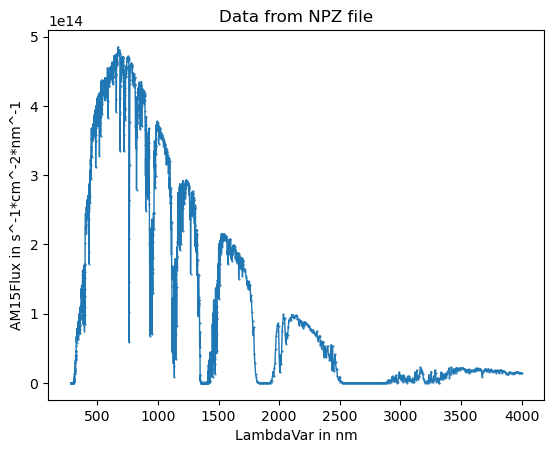

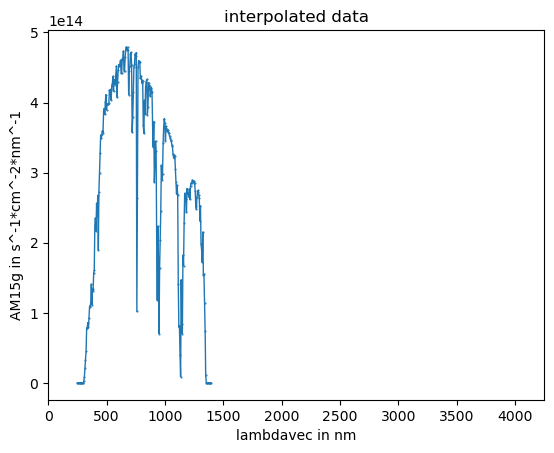

[(200.0, 1400.0)]

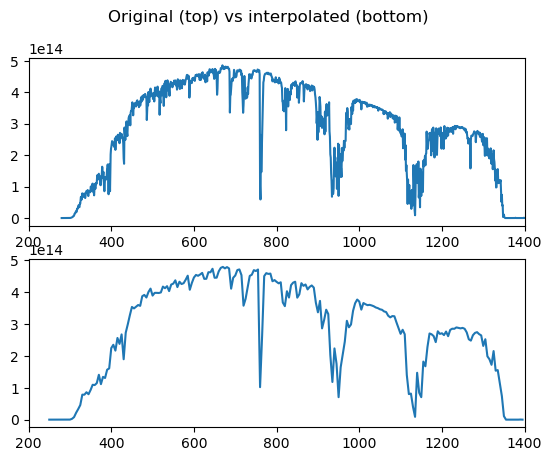

In [3]:
# Parameters #

data = np.load("./data/AM15g_spectrum.npz")  # load AM1.5g spectrum
# LambdaVar in nm, and AM15gFlux in s^-1*cm^-2*nm^-1

# visualize AM15g spectrum
x1 = data["LambdaVar"]
y1 = data["AM15gFlux"]
plt.plot(x1, y1, marker=".", linewidth=1, markersize=1)
plt.xlabel("LambdaVar in nm")
plt.ylabel("AM15Flux in s^-1*cm^-2*nm^-1")
plt.title("Data from NPZ file")
plt.show()

# generate a well-defined version
lambda_vec = np.arange(250, 1400, 5)  # vector of wavelengths in nm
AM15g = np.interp(lambda_vec, data["LambdaVar"], data["AM15gFlux"])

# visualize interpolated version
x2 = lambda_vec
y2 = AM15g
plt.plot(x2, y2, marker=".", linewidth=1, markersize=1)
plt.xlim(0, 4250)
plt.xlabel("lambdavec in nm")
plt.ylabel("AM15g in s^-1*cm^-2*nm^-1")
plt.title("interpolated data")
plt.show()

# visually compare
fig, ax = plt.subplots(2)
fig.suptitle("Original (top) vs interpolated (bottom)")
ax[0].plot(x1, y1)
ax[0].set(xlim=(200, 1400))
ax[1].plot(x2, y2)
ax[1].set(xlim=(200, 1400))

In [4]:
# top cell parameters [Lead Halide Perovskite FACsPbIBr]
EgapP = 1.7  # bandgap (eV)d
pvk_thick = 800e-7  # cm
Rsh_pvk = 200e3  # Shunt resistance in ohms.cm2
J01d_pvk = 8e-24  # A/cm2
J02_pvk = 2.1e-13  # A/cm2
J0def_pvk = 3e-23  # A/cm2
Rdef_pvk = 12  # ohms.cm2

w = 1  # Unit cell dimensions (cm)
l = 2  #  pitch (cm) 

# bottom cell parameters [Silicon]
EgapSi = 1.12  # bandgap (eV)
Rsh_Si = 50e3  # Shunt resistance (ohms.cm2)
Waf_thick = 0.019  # cm
Ndop = 5e14  # Doping concentration (cm^-3)
dop_type = -1  # n-type -1, p-type +1
ni = 9.65e9  # Intrinsic carrier concentration (cm^-3)
n_def = 1  # ideality factor for SRH recombination
J0n_Si = 2e-15  # A/cm2 -- (dark) saturation current density due to diffusion and SRH

C_aug = 2.945e-30  # Auger recombination coefficient (cm^6/s)
J0Aug_Si = q * C_aug * ni**3 * Waf_thick  # Auger recombination current A/cm2

# combined series resistance from internal transport factors
RserInt = 1.5 + 4.7e-3  # ohms.cm2 - internal series resistance (pvk + Si).

# Black body spectrum at 300K temperature
BB300K = (
    2 * np.pi * c / ((lambda_vec * 1e-9) * lambda_vec * (lambda_vec * 1e-7) ** 2)
) * (
    1.0 / (np.exp(hc / (lambda_vec * Vt)) - 1)
)  # embedded unit conversions --what are the final units on this??

### <mark>Mikael questions</mark>

1. Why $l=2$, doesn't this lead to an active area of 1 cm^2?
   - are we only considering half the cell at a time?
2. Can we rewrite the exponential multipliers in `BB300K` to make it clear what is going on?


### Top cell

| Symbol      | ideality | Diode | Physical Interpretation                      | Magnitude [A/cm2] | Notes               |
| ----------- | -------- | ----- | -------------------------------------------- | ----------------- | ------------------- |
| `J0_pvk`    | n = 1    | `J01` | Radiative recombination                      | 2e-24             | Primary `J0` term   |
| `J01d_pvk`  | n = 1    | `J01` | n = 1 recombination pathway                  | 8e-24             | Added to `J0_pvk`   |
| `J02_pvk`   | n = 2    | `J02` | SRH trap-assisted recombination              | 2e-13             | Standard `J02` term |
| `J0def_pvk` | n = 1    | `J0d` | Enhanced defect recombination and resistance | 3e-23             | Diode + Resistor    |

### Bottom cell

| Symbol     | ideality | Diode    | Physical Interpretation                          | Magnitude [A/cm2] | Notes                        |
| ---------- | -------- | -------- | ------------------------------------------------ | ----------------- | ---------------------------- |
| `J0_Si`    | n = 1    | `J01`    | Radiative recombination                          | 4e-16             |                              |
| `J0Aug_Si` | n = 2/3  | `J0,2/3` | Intrinsic Auger recombination                    | 8e-21             |                              |
| `J0n_Si`   | n = 1    | `J01,d`  | n = 1 recombination pathway, diffusion and SRH   | 2e-15             | NOT equivalent to `J01d_pvk` |


In each sub-cell the radiative dark current is given by:

$ J\_{01} = q \int BB(\lambda) \cdot EQE(\lambda) d\lambda $, with $ BB(\lambda) = \frac{2\pi c}{\lambda^4} \cdot \frac{1}{e^{hc/\lambda kT} - 1} $.

The short-circuit current for the perovskite is:

$ J\_{sc,P} = q \int AM1.5G(\lambda) \cdot EQE_P(\lambda) d\lambda $,

with $ EQE_P(\lambda) = T_{x,{front}} \cdot (1 - e^{- \alpha(\lambda) W}) $.

Here, $T_{x,{front}}$ represents the percentage of light transmitted through the front layer stack, comprising the TCE plus any additional layers: ARC, ETL, buffers. W represents the perovskite absorber thickness, and $\alpha$ the absorption coefficient (which should be obtained experimentally).


### <mark>Mikael notes</mark>
Below is some code that allows us to artificially shift the bandgap of the perovskite, and update the optical constants. This is useful as there are not experimental results available for all bandgaps. One example that uses a Krames-Kronig transformation instead of the Tauc approach can be found in the supplementary of *Optimizing Energy Yield of Monolithic Perovskite/Silicon Tandem Solar Cells in Real-World Conditions: The Impact of Luminescent Coupling* (K. Nguyen et. al., 2025)

Met condition, breaking


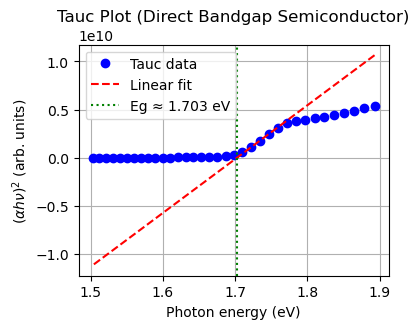

In [5]:
# tauc analysis of the absorption coefficient in the perovsite

file_path = "./data/CsFaPbIB_1,72_Tejada2018.csv"
df_pvk0 = pd.read_csv(file_path)

Erange = [
    EgapP - 0.2,
    EgapP + 0.2,
]  # specify the range of energy to do the tauc fitting

results = []
i = 1
lambda_shift = 0

while i < 1000:
    E_gap, df_new_nk = tandex.tauc_analysis(
        df_pvk0, lambda_shift, lambda_vec, Erange, plot=False
    )
    results.append({"lambda_shift": lambda_shift, "E_gap": E_gap})
    if np.abs(E_gap - EgapP) < 0.004:
        print("Met condition, breaking")
        break
    if E_gap > EgapP:
        lambda_shift += 1
    elif E_gap < EgapP:
        lambda_shift -= 1
    i += 1
E_gap, df_new_nk = tandex.tauc_analysis(
    df_pvk0, lambda_shift, lambda_vec, Erange, plot=True
)

# write new file with the modified nk data
df_new_nk.to_csv(r"./data/pvk_nk_data.csv", index=False)

### <mark>Mikael notes</mark>

Tauc analysis is a way to calculate bandgap.
We import a csv with experimental results:

| lambda_n | n     | lambda_k | k     | alpha    |
| -------- | ----- | -------- | ----- | -------- |
| 192.130  | 1.784 | 190.641  | 0.496 | 326800.0 |
| 196.331  | 1.760 | 191.517  | 0.544 | 356700.0 |
| 200.640  | 1.769 | 192.372  | 0.570 | 372100.0 |
| 204.949  | 1.788 | 193.214  | 0.597 | 388500.0 |
| 209.257  | 1.801 | 194.883  | 0.622 | 401100.0 |
| ...      | ...   | ...      | ...   | ...      |

And we feed the estimated energy bandgap based on literature
Then, there is the tauc fit on experimental data where some lambda shift takes place. In this case, +8, which gets incorporated into the lambda_k values (each value goes up by 8), and a new file is written. This is a calibration step?


For silicon, light filtering through the PVK and Lambertian light trapping from textures lead to a short-circuit current given by:

$ J_{sc,Si} = q \int AM1.5G(\lambda) \cdot (1 - EQE_P(\lambda)) \cdot EQE_{Si}(\lambda) d\lambda $,

with

$ EQE_{Si} = T_{x,{mid}} \cdot \frac{1 - \exp(-2Z \alpha W)}{1 - (1 - 1/n^2) \cdot \exp(-2Z \alpha W)} $

where $T_{x,{mid}}$ represents the transmission through any layers in the middle, interconnecting the two cells.

The optical pathlength enhancement factor (Z) can be obtained as: $ Z(\lambda) = \frac{2 + a( \alpha W)^b}{1 + a( \alpha W)^b} $. ( a=0.935 and b=0.67 following Green’s model)

_Note_: make sure the ./data/ folder has a .csv file for the optical properties of the Si and PVK absorbers to be used. They will be called by the functions that calculate Jsc.


### we can now calculate tandem efficiency as a function of TCO sheet resistances and transmittances


Note: can't find the initialization file spinit.
Unsupported Ngspice version 41


Maximum Efficiency: 36.72 %
Jsc: 21.06 mA/cm^2, Si Jsc: 21.16 mA/cm^2, Pvk Jsc: 23.02 mA/cm^2
Voc: 1.98 V
FF: 0.88


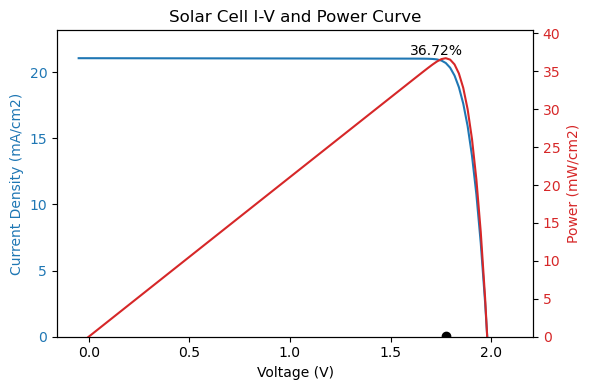

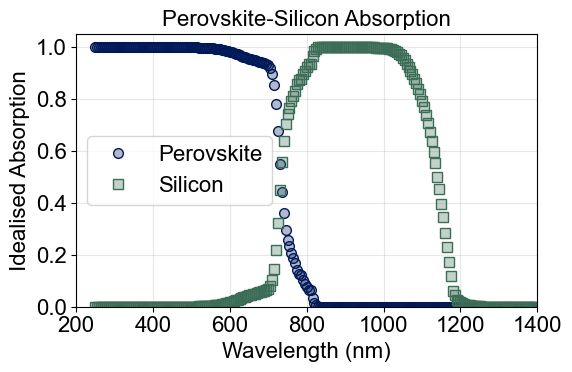

In [6]:
# Simulation #
#start = time.time()  # can monitor the time taken for the simulation

w = 0.2  # Unit cell dimensions (cm)
l_values = np.linspace(
    0.02, 0.7, 100
)  # range of values to extract optimal pitch l (cm)
d = 20e-4  # Contact width in cm
Vcell = np.linspace(-0.05, 2.1, 100)  # the voltage range for the cell simulation

R_tco_vec = np.logspace(1, np.log10(3000), 10)  # TCO sheet resistance (ohm/sq)

Tx_vec = np.linspace(0.85, 1, 10)  # TCO transmittance, 85%-100% range

# Initialize arrays
eff_vec = np.zeros([np.size(R_tco_vec), np.size(Tx_vec)])
Jsc_vec = np.zeros([np.size(R_tco_vec), np.size(Tx_vec)])
Voc_vec = np.zeros([np.size(R_tco_vec), np.size(Tx_vec)])

# Loop over TCO transmittance values (Tx)
for ind2, Tx in enumerate(Tx_vec):

    # calculate the generation rates, and Jsc based on the TCO transmittance Tx (A/cm2) [ideal case!]
    Jsc_pvk, AM15g_after_pvk, Abs_pvk = tandex.Jsc_pvk_func(
        lambda_vec, Tx * AM15g, pvk_thick, EgapP, df_pvk0
    )
    
    Jsc_Si, AxSi = tandex.Jsc_Si_func(Waf_thick, lambda_vec, AM15g_after_pvk)
    
    # calculate external quantum efficiency for both cells
    EQE_pvk = Abs_pvk
    #EQE_Si = AxSi
    EQE_Si = AxSi * (AM15g_after_pvk / AM15g)

    # calculate radiative dark saturation currents
    J0_pvk = q * np.trapezoid(
        BB300K * EQE_pvk, lambda_vec
    ) 
    J0_Si = q * np.trapezoid(BB300K * EQE_Si, lambda_vec)  # (y-values, x-values)

    # Loop over the TCO sheet resistance values (R_tco)
    for ind1, R_tco in enumerate(R_tco_vec):

        # calculate optimal pitch and thus active area fraction
        AAF = (
            1 - d / l_values
        )  # Initial Active Area Fractions, assuming d = 20 um contact width
        l, _, _, _, _ = tandex.find_optimal_pitch(
            J0_Si, J0n_Si, J0Aug_Si, Rsh_Si, Jsc_Si, l_values, R_tco, AAF
        )  # inputs: radiative, non-radiative, auger, shunt resistance, generated current, pitch values, resistance of TCO, AAF
        AAF = 1 - d / l

        # Re-calculate the currents, based on the optimal pitch. Units of Amperes
        # perovskite top cell
        Isc_pvk = -AAF * w * (l / 2) * Jsc_pvk
        I0_pvk = w * (l / 2) * J0_pvk
        I01d_pvk = (w * (l / 2)) * J01d_pvk

        # silicon bottom cell
        Isc_Si = -AAF * w * (l / 2) * Jsc_Si
        I01_Si = w * (l / 2) * J0_Si

        Rser = (
            R_tco * (l**2 / (12)) + RserInt
        )  # series resistance in ohms.cm^2 [TCO + internal]

        # top cell parameters: Isc_pvk, Rsh_pvk, I0_pvk, I0def_pvk, Rdef_pvk, I02_pvk
        top_cell = [
            Isc_pvk,
            Rsh_pvk / (w * (l / 2)),
            I0_pvk + I01d_pvk,
            J0def_pvk * w * (l / 2),
            Rdef_pvk / (w * (l / 2)),
            J02_pvk * w * (l / 2),
        ]
        # bottom cell parameters: Isc_Si, Rsh_Si, I01_Si, I0Aug_Si, I0d_Si, n_def
        bottom_cell = [
            Isc_Si,
            Rsh_Si / (w * (l / 2)),
            I01_Si,
            J0Aug_Si * w * (l / 2),
            J0n_Si * w * (l / 2),
            n_def,
        ]

        voltages, currents = tandex.simulate_circuit(
            top_cell, bottom_cell, Rser, w, l, Vcell
        )

        eff, Jsc, Voc, FF = tandex.calculate_efficiency(voltages, currents, False)
        if ind1 == 0 and ind2 == np.size(Tx_vec) - 1:
            print(f"Maximum Efficiency: {eff:.2f} %")
            print(
                f"Jsc: {Jsc*1e3:.2f} mA/cm^2, Si Jsc: {Jsc_Si*1e3:.2f} mA/cm^2, Pvk Jsc: {Jsc_pvk*1e3:.2f} mA/cm^2"
            )
            print(f"Voc: {Voc:.2f} V")
            print(f"FF: {FF:.2f}")
            eff, Jsc, Voc, FF = tandex.calculate_efficiency(voltages, currents, True)

        eff_vec[ind1, ind2] = eff
        Jsc_vec[ind1, ind2] = Jsc
        Voc_vec[ind1, ind2] = Voc

plt.figure(figsize=(6,4))

import numpy as np
import matplotlib.pyplot as plt
from cmcrameri import cm
import matplotlib as mpl
from cycler import cycler

# set default figure properties for all subsequent plots
mpl.rcParams.update({
    'figure.figsize': (6,4),
    'font.family': 'arial',
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'legend.fontsize': 16,
    'lines.linewidth': 1.5,
    'savefig.dpi': 300
})

# Create a matplotlib-style palette from batlow
palette = cm.batlow(np.linspace(0, 1, 5))


# Colors and markers to cycle through
n = 4 # number of lines to plot

colors = cm.batlow(np.linspace(0, 1, n))
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '<']
markers = markers[:n]  # limit to n markers

# Semi-transparent fills based on the same colors
face_alpha = 0.3
face_colors = [(*c[:3], face_alpha) for c in colors]

# Global plotting style
mpl.rcParams['axes.prop_cycle'] = (
    cycler(color=colors) +
    cycler(marker=markers) +
    cycler(markerfacecolor=face_colors) +
    cycler(markeredgecolor=colors)
)
mpl.rcParams['lines.linestyle'] = 'None'
mpl.rcParams['lines.markersize'] = 7
mpl.rcParams['lines.linewidth'] = 1.5




plt.plot(lambda_vec, EQE_pvk, label="Perovskite")
plt.plot(lambda_vec, EQE_Si,  label="Silicon")

plt.xlim(200, 1400)
plt.ylim(0, 1.05)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Idealised Absorption")
plt.title("Perovskite-Silicon Absorption")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



    # for long simulation times, uncomment the following lines to print progress
    # end = time.time()
    # print(f"Elapsed time: {end - start:.2f} seconds, ind1={ind1}, ind2={ind2}")

## <mark> Mikael notes </mark>
The absorption curve for pvk starts at 1 not zero because we are considering the *ideal* scenario with no reflection, no scattering, and an optically thick perovksite cell... This is technically not an EQE curve either because we are not considering any recombination. We're plotting an *ideal absorbtion curve*. Note that we are assuming no wavelength dependence for the TCO transmittance.

## We can now get a plot of efficiency as a function of R_sh_tco and T_x


<a list of 6 text.Text objects>

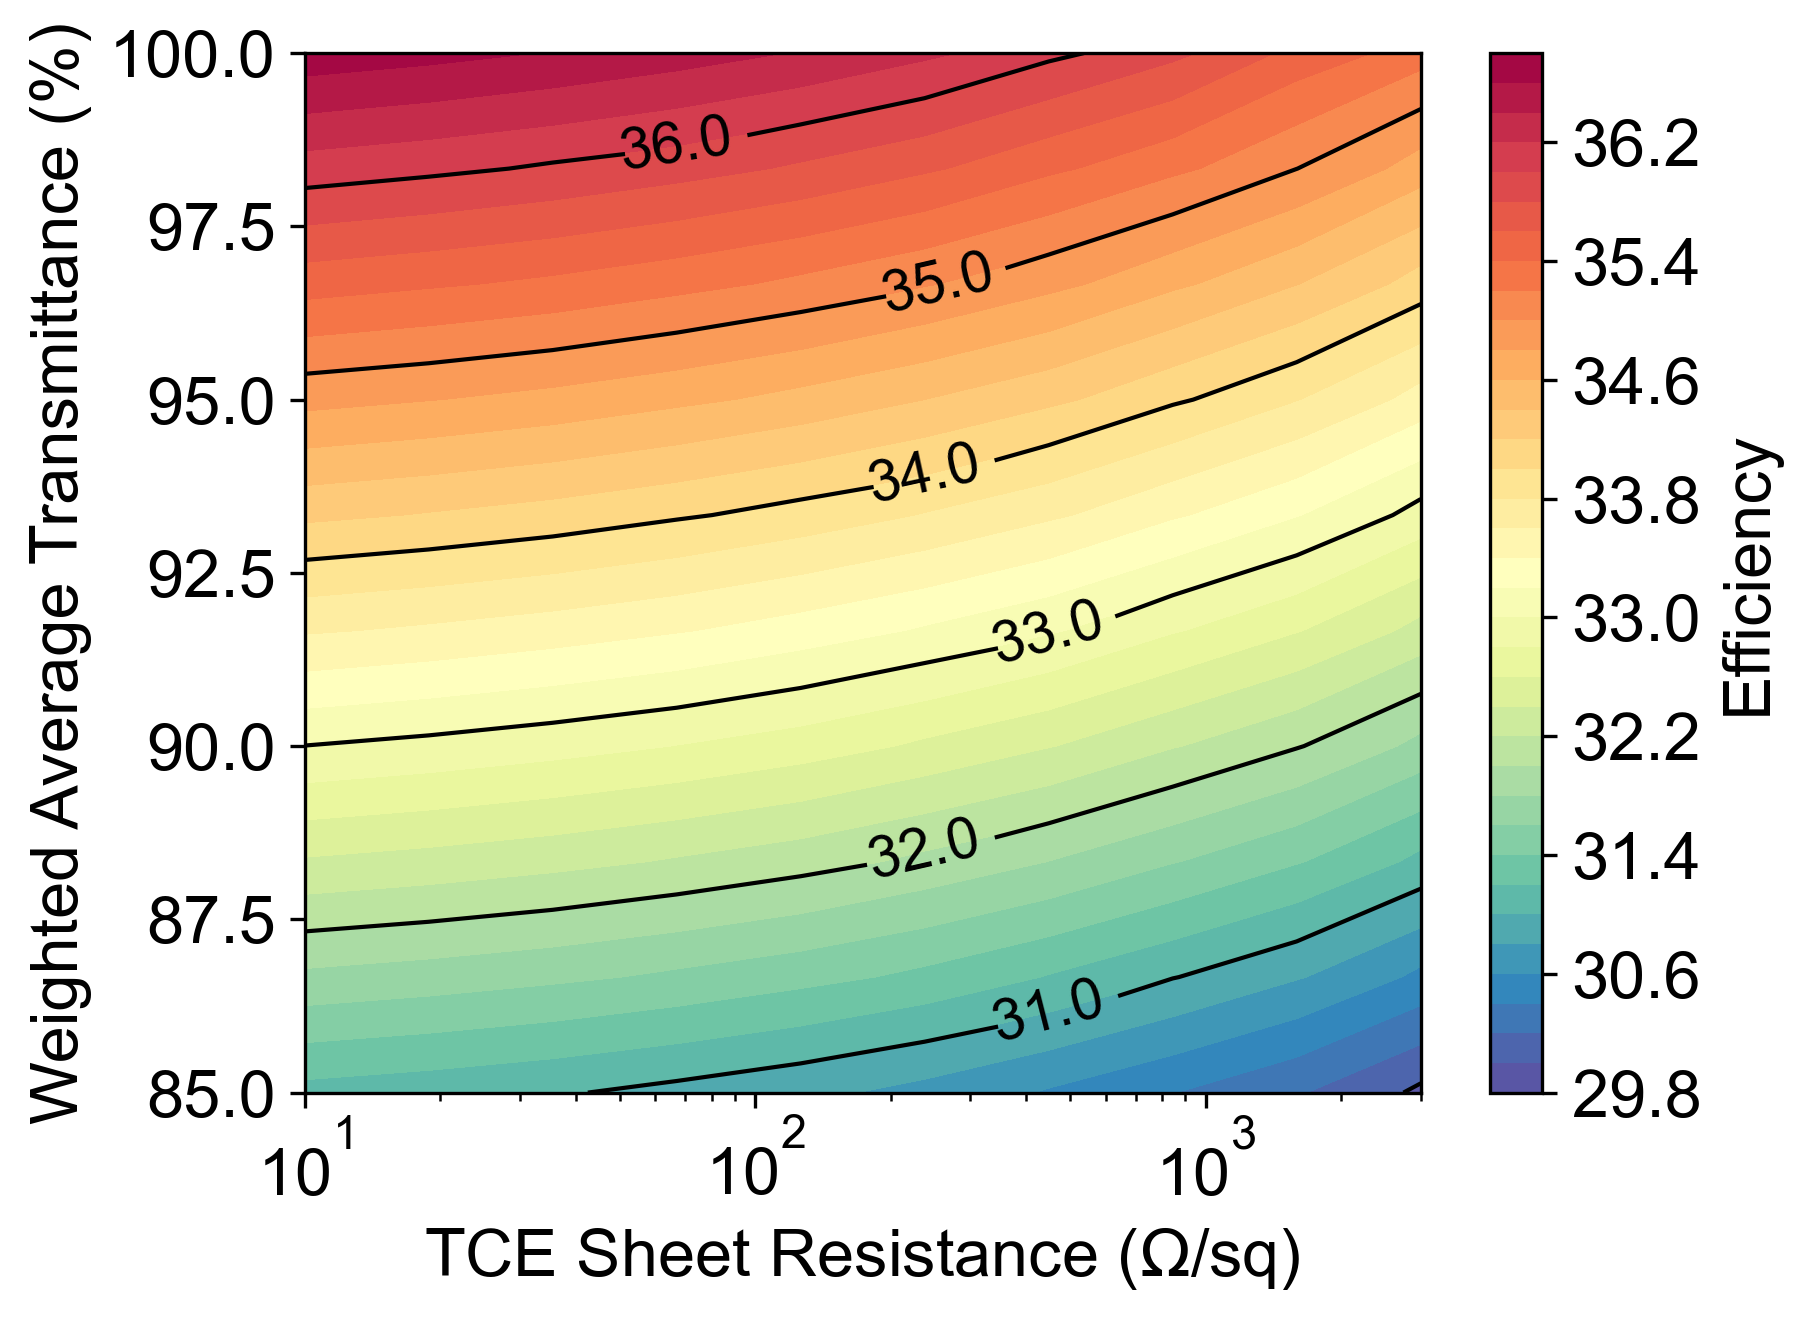

In [7]:
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 16
dum = Jsc_vec.max(axis=0) / np.max(Jsc_vec)

plt.figure(figsize=(6, 4.5))
contour = plt.contourf(
    R_tco_vec, 100 * Tx_vec, np.transpose(eff_vec), levels=40, cmap="Spectral_r"
)
cbar = plt.colorbar(contour, label="Efficiency")
plt.xscale("log")
plt.xlabel(r"TCE Sheet Resistance ($\Omega$/sq)")
plt.ylabel(r"Weighted Average Transmittance (%)")
# plt.title(r'$T_x$ and $R_s$ limited efficiency')
plt.ylim(85, 100)

# Add contour lines and labels
contour_lines = plt.contour(
    R_tco_vec, 100 * Tx_vec, np.transpose(eff_vec), levels=6, colors="k", linewidths=1
)
plt.clabel(contour_lines, inline=True, fontsize=14, fmt="%.1f")

<mark>Mikael notes</mark>
We can interpolate efficiency at a specific point on the 2d grid if we want a value rather than having to visually get it from the graph. We use the function below to do it. An example case is shown.


In [8]:
from scipy.interpolate import RegularGridInterpolator

# Create a 2D interpolation function for eff_vec as a function of Rsheet (R_tco_vec) and Tx (Tx_vec)
# eff_vec should be a 2D array with shape (len(Tx_vec), len(R_tco_vec))
eff_interp_func = RegularGridInterpolator(
    (R_tco_vec, Tx_vec),
    eff_vec,  # transpose because interp2d expected (x,y)->z with different orientation
    method="linear",
    bounds_error=False,
    fill_value=None,
)

# Example usage:
interpolated_eff = eff_interp_func([[10, 0.925]])[0]  # Rsheet=100 Ω/sq, Tx=0.92
print("Interpolated efficiency:", interpolated_eff)

Interpolated efficiency: 33.93056704209239


## <mark>Mikael notes</mark>

With the graph and the interpolation function above, we can now estimate efficiency

If we import experimental Weighted Average Transmission (WAT) and TCE Sheet Resistance


Interpolated efficiency: [34.95016028]
Interpolated efficiency: [31.15610277]
Interpolated efficiency: [31.26588626]
[ 20  30  40  50  70  90 120]


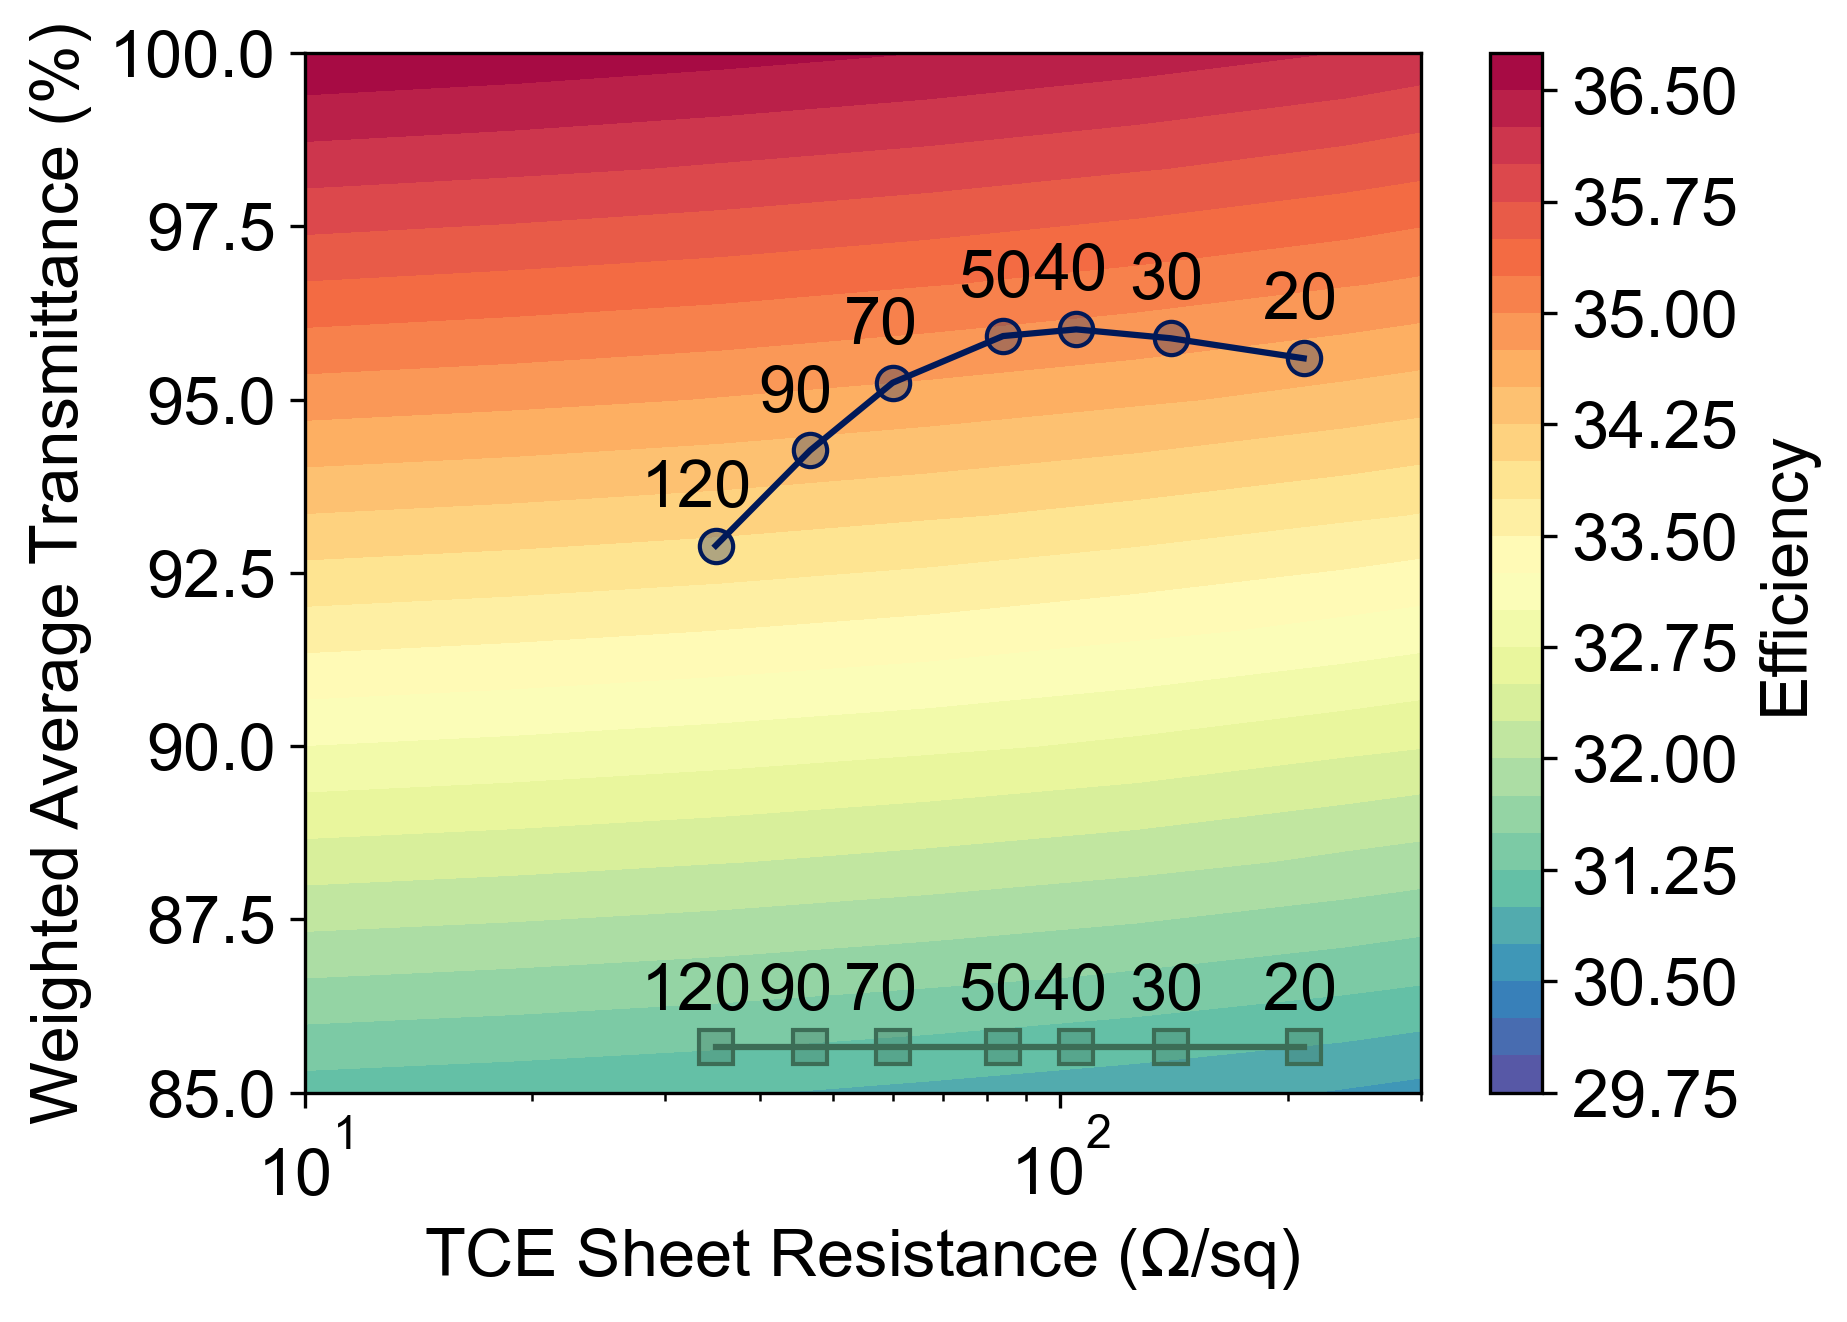

In [9]:
import os
from os.path import join, isfile

plt.figure(figsize=(6, 4.5))
contour = plt.contourf(
    R_tco_vec, 100 * Tx_vec, np.transpose(eff_vec), levels=30, cmap="Spectral_r"
)
plt.xscale("log")
plt.ylabel(r"Weighted Average Transmittance (%)")
plt.xlabel(r"TCE Sheet Resistance ($\Omega$/sq)")
cbar = plt.colorbar(contour, label="Efficiency")

plt.ylim(85, 100)
plt.xlim(10, 300)

# the Sheet Res and WAT has been calculated for ITO in Koida's 2022 Paper.
folder_path = r"./data/TCE_data/"  # replace with your folder path
numid = [0, 1, 2, 3, 4, 6, 9]
thickness_2 = np.array([20, 30, 40, 50, 70, 90, 120])  # specify thicknesses of interest

markers = [
    "-o",
    "-s",
    "-D",
    "-v",
    "-^",
    "-P",
    "-*",
    "-X",
    "-<",
    "->",
]  # Add more if needed
i = 0

for file in sorted(os.listdir(folder_path)):
    if file.endswith(".npz"):
        file_path = join(folder_path, file)
        if isfile(file_path):
            data = np.load(
                file_path
            )  # npz file with keys: Rsh, WAT_Tx, thickness, ARC_thick

            Rsh = data["Rsh"]
            WAT_Tx = data["WAT_Tx"]
            thickness = data["thickness"]
            ARC_thick = data["ARC_thick"]

            WAT_Tx2 = np.interp(
                thickness_2, thickness, WAT_Tx
            )  # interpolate WAT_Tx at thicknesses of interest
            Rsh2 = np.interp(
                thickness_2, thickness, Rsh
            )  # interpolate Rsh at thicknesses of interest

            plt.plot(Rsh2, WAT_Tx2 * 100, markers[i], label=f"{file}", markersize=8)

            interpolated_eff = eff_interp_func(
                [[Rsh2[3], WAT_Tx2[3]]]
            )  # Interpolate efficiency using function above; Rsheet=100 Ω/sq, Tx=0.92
            print("Interpolated efficiency:", interpolated_eff)

            for j in range(len(thickness_2)):
                plt.text(
                    Rsh2[j] - 2,
                    WAT_Tx2[j] * 100.4,
                    f"{thickness_2[j]:.0f}",
                    fontsize=16,
                    ha="center",
                    va="bottom",
                )

            i += 1

interpolated_eff = eff_interp_func([[Rsh2[6], WAT_Tx2[6]]])  # Rsheet=100 Ω/sq, Tx=0.92
print("Interpolated efficiency:", interpolated_eff)

print(thickness_2)
# plt.savefig('eff_map_plot_v4.png', dpi= 300,bbox_inches='tight')
plt.show()

## The efficiency limit of a perovskite single junction

For evaluating the ultimate limit of a single junction it is best to ignore the loss contributions from the TCEs by assuming no lateral resistance to the metal contact. This is equivalent to having full area metal contacts. We can also ignore any optical losses, assuming all light is coupled into the PVK.

We can then concentrate on the bandgap and thickness of the absorber, and all the quality parameters (J0 and ideality factors for recombination processes).

To estimate voltage loss in perovskites, we follow Allen's approach, setting the external radiative efficiency as an evaluation of the perovskite cell quality:

$ ERE = \frac{e^{V*{oc}/V_t} \cdot J*{0,{rad}}}{J\_{sc}} $.

And we use the knowledge of the best pervoskite cell efficiencies reproted in the literature (for the noted Egap) to find circuit parameters that well reflect the current state of the field, and the possible improvements in perovskite device passivation to reach 10% ERE.

So we first define the pvk parameters:


In [10]:
# top cell parameters [Perovskite]
EgapP = 1.7  # bandgap (eV)d
pvk_thick = 800e-7  # cm
Rsh_pvk = 200e3  # Shunt resistance in ohms.cm2
J01d_pvk = 8e-24  # A/cm2
J02_pvk = 2.1e-13  # A/cm2
J0def_pvk = 3e-23  # A/cm2
Rdef_pvk = 12  # ohms.cm2
RserInt = 1.5  # ohms.cm2 - internal series resistance.

w = 1  # Unit cell dimensions (cm)
l = 2  #  pitch (cm) (such that the active area is 1 cm^2)

and then calculate the cell efficiency:


Efficiency= 24.17, Jsc = 23.02190 mA/cm^2, Voc = 1.25302 V, FF = 83.79181 % 
J0_pvk = 2.57718e-24 A/cm^2
ERE = 12.56 %


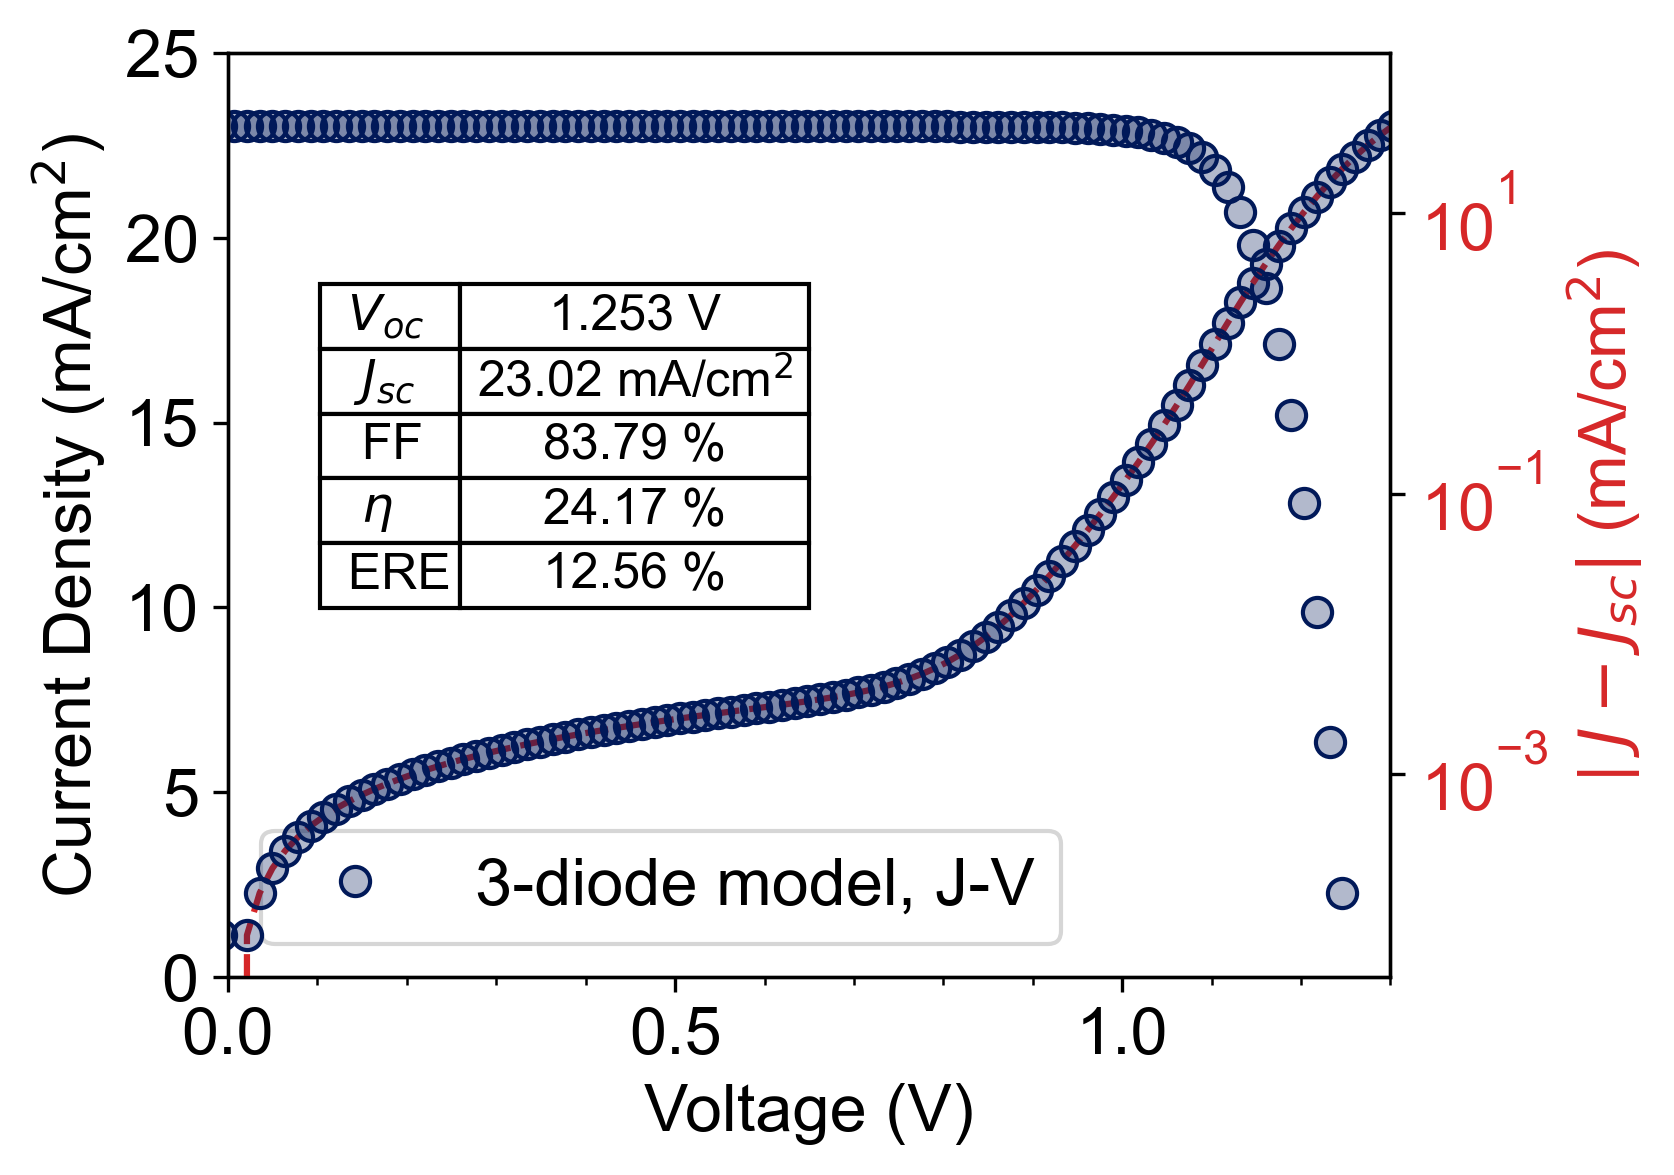

In [11]:
# Perovskite top cell single junction simulation
Vcell = np.linspace(
    -0.05, (EgapP) * 0.8, 100
)  # the voltage range for the cell simulation

# calculate the generation rates, and Jsc (A/cm2)
Jsc_pvk, _, Abs_pvk = tandex.Jsc_pvk_func(lambda_vec, AM15g, pvk_thick, EgapP, df_pvk0)
J0_pvk = q * np.trapezoid(BB300K * Abs_pvk, lambda_vec)
AAF = 1  # Active Area Fraction

# perovskite top cell currents in Amps
Isc_pvk = -AAF * w * (l / 2) * Jsc_pvk
I0_pvk = w * (l / 2) * J0_pvk
I01d_pvk = w * (l / 2) * J01d_pvk

Rser = 0 + RserInt  # series resistance in ohms.cm^2 [TCO + internal]

# top cell parameters: Isc_pvk, Rsh_pvk, I0_pvk, I0def_pvk, Rdef_pvk, I02_pvk
top_cell = [
    Isc_pvk,
    Rsh_pvk / (w * (l / 2)),
    I0_pvk + I01d_pvk,
    J0def_pvk * w * (l / 2),
    Rdef_pvk / (w * (l / 2)),
    J02_pvk * w * (l / 2),
]

voltages, currents = tandex.simulate_pvk_sj(top_cell, Rser, w, l, Vcell)

eff, Jsc, Voc, FF = tandex.calculate_efficiency(voltages, currents, False)
ERE = np.exp((q * Voc) / (k * T)) * I0_pvk / (Jsc * (w * (l / 2)))
print(
    f"Efficiency= {eff:.2f}, Jsc = {1e3*Jsc:.5f} mA/cm^2, Voc = {Voc:.5f} V, FF = {0.1*eff/(Voc*Jsc):.5f} % "
)
print(f"J0_pvk = {J0_pvk:.5e} A/cm^2")
print(f"ERE = {100*ERE:.2f} %")

# plot the IV curve
tandex.plot_pvk_iv_curve(voltages, currents, eff, Jsc, Voc, FF, ERE)

## The efficiency limit of a silicon single junction

The implied voltage and current densities can be modelled via the knowledge of intrinsic and extrinsic recombination in silicon:

$ iV = \frac{kT}{q} \ln \left( \frac{\Delta n (N + \Delta n)}{n*{i,{eff}}^2} \right) $ and $ iJ = J*{sc} - \frac{qW\Delta n}{ \tau\_{{eff}}} $,

with $ \tau*{{eff}}^{-1} = \tau*{{int}}^{-1} + \frac{J*{0s}(N + \Delta n)}{q W n*{i,{eff}}^2 } $.

This allows to define a pseudo J-V curve (https://doi.org/10.1016/j.solmat.2022.111914).

This seciton is dedicated to finding circuit model parameters that reproduce such pseudo J-V plot, for a given value of total surface recombination velocity, as obtained from the J0s parameter.

We also ignore here the losses originating from TCEs.

Begin by defining the silicon circuit model parameters:


## <mark>Mikael notes</mark>

### Read that paper


In [12]:
# bottom cell parameters [Silicon]
EgapSi = 1.12  # bandgap (eV)
Rsh_Si = 50e3  # Shunt resistance (ohms.cm2)
Waf_thick = 0.019  # cm
Ndop = 5e14  # Doping concentration (cm^-3)
dop_type = -1  # n-type -1, p-type +1
ni = 9.65e9  # Intrinsic carrier concentration (cm^-3)
n_def = 1  # ideality factor for SRH recombination
J0n_Si = 2e-15  # A/cm2

C_aug = 2.945e-30  # Auger recombination coefficient (cm^6/s)
J0Aug_Si = q * C_aug * ni**3 * Waf_thick  # A/cm2

# combined series resistance from internal factors
RserInt = 1e-12  # ohms.cm2 - internal series resistance.

w = 1  # Unit cell dimensions (cm)
l = 2  #  pitch (cm) (such that the active area is 1 cm^2)

### Calculating Silicon Internal Series Resistivity

The internal series resistivity of a silicon sub-cell uses carrier lifetimes, excess carrier densities, and material resistivity.

We begin by defining a range of excess carrier densities, spanning from $10^9$ to $10^{18} cm^{-3}$, to simulate various injection levels. Using a material model (`Si_bulk_lifetime`), we compute the Auger and radiative lifetimes as well as the effective intrinsic carrier concentration $n_{i,\text{eff}}$, all as functions of doping and excess carrier density.

The total effective carrier lifetime $\tau_{\text{eff}}$ is calculated by summing the individual recombination rates:

$$
\tau_{\text{eff}} = \left( \frac{1}{\tau_{\text{Aug}}} + \frac{1}{\tau_{\text{Rad}}} + \frac{J_0 (N + \Delta n)}{q W n_{i,\text{eff}}^2} \right)^{-1}
$$

This includes Auger, radiative, and SRH-like recombination components.

To estimate the carrier density under illumination, we use the steady-state approximation in Voc conditions:

$$
\Delta n = \frac{J_{\text{sc}} \cdot \tau_{\text{eff}}}{q \cdot W}
$$

The value of $\Delta n$ closest to this estimate is selected from the previously defined range to represent the actual operating point.

Next, the resistivity of silicon at this injection level is determined using a doping- and injection-dependent resistivity model (Klassen's mobility as implemented in https://www2.pvlighthouse.com.au/calculators/Mobility%20calculator/Mobility%20calculator.aspx). The internal series resistance of the silicon is given by the average travel distance for carriers (one wafer thickness):

$$
R_{\text{ser,Si}} = \rho_{\text{Si}} \cdot W
$$

This is the internal ohmic loss of the silicon absorber in units of $\Omega \cdot \text{cm}^2$, and is a critical factor in determining the fill factor and overall efficiency of the device.


Silicon Internal Series Resistivity = 4.70e+00 mOhms.cm^2
Pseudo J-V curve results:
Implied Efficiency: 29.0396, Jsc = 44.1849 mA/cm^2,Voc = 741.5025 mV,FF = 88.6347 %
0.0046967857274877334
0.04417918492258366 0.0002075001651964322 0.28475772296637597 0.2849652231315724
MSE is: 1.148

3-diode Si single junction including internal Rser:
Efficiency= 28.91, Jsc = 44.17926 mA/cm^2, Voc = 741.14 mV, FF = 88.29008 % 
J0_Si = 4.36594e-16 A/cm^2
J0Aug_Si = 8.05622e-21 A/cm^2


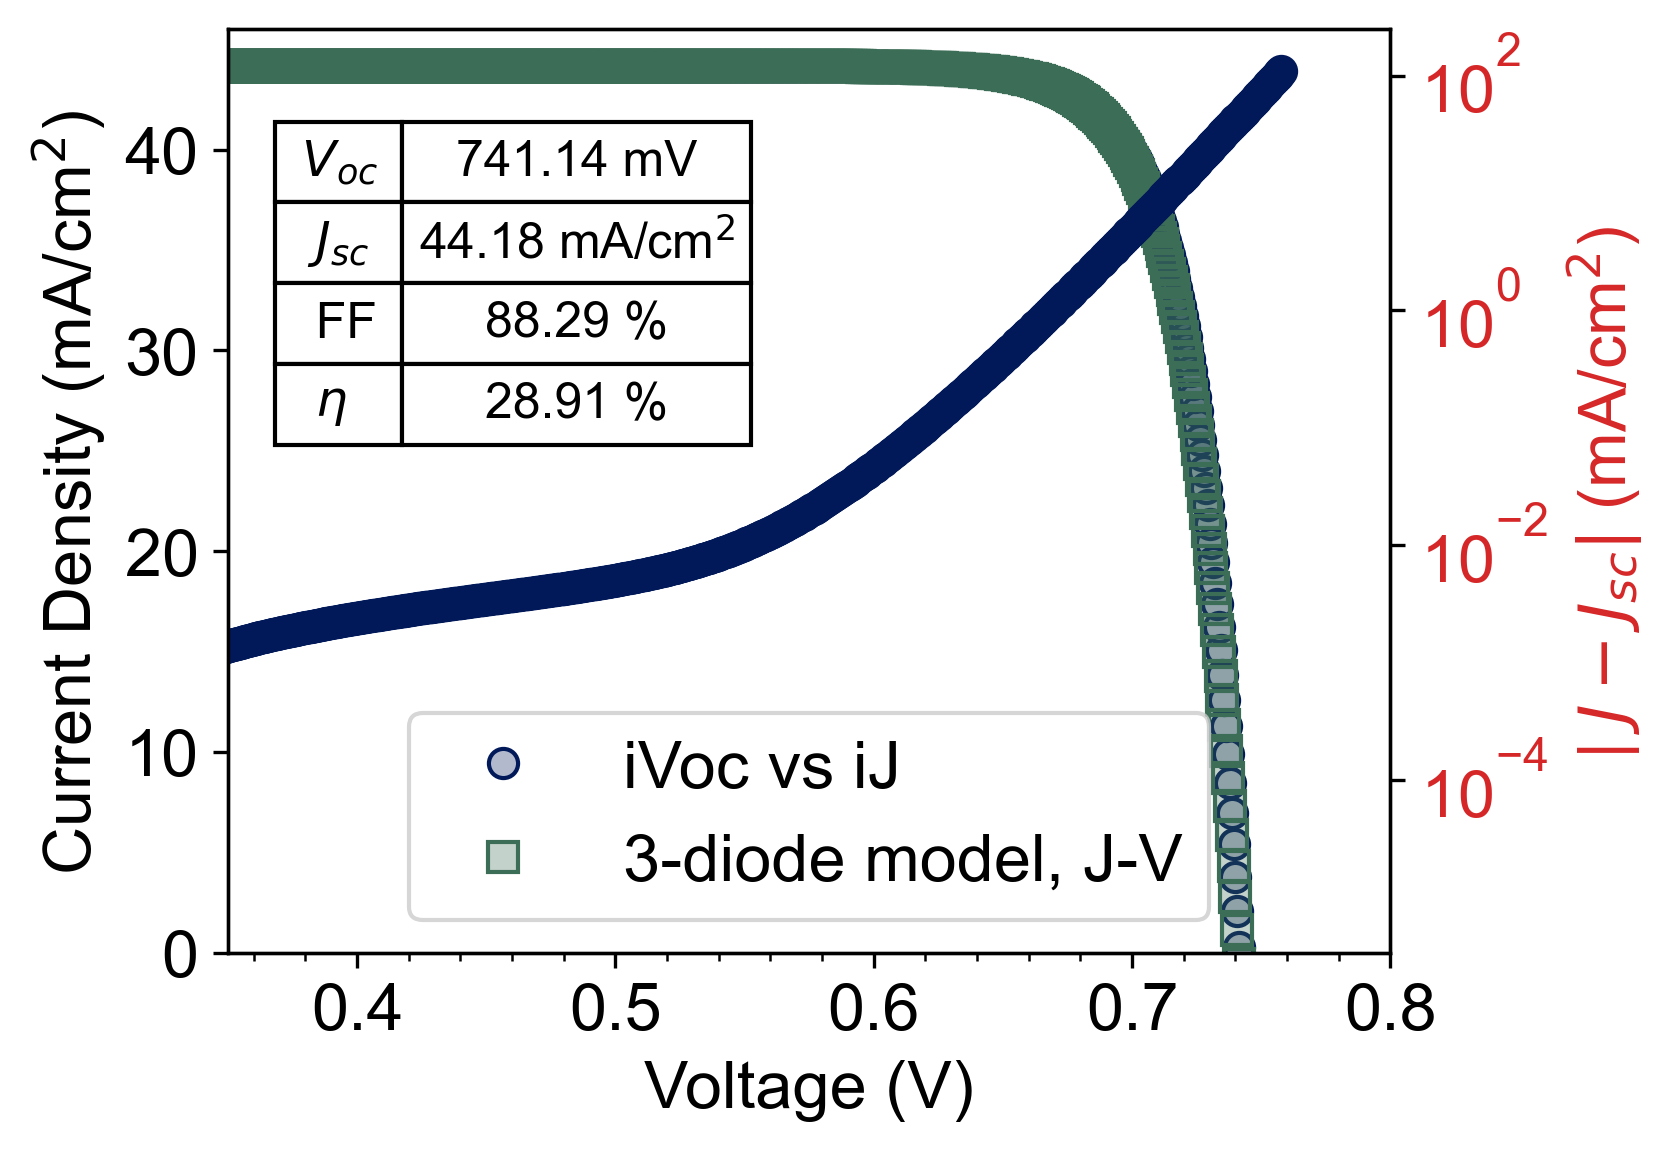

[2.30785889e-08 2.34215645e-08 2.37696373e-08 2.41228828e-08
 2.44813780e-08 2.48452008e-08 2.52144306e-08 2.55891475e-08
 2.59694333e-08 2.63553705e-08 2.67470433e-08 2.71445369e-08
 2.75479377e-08 2.79573336e-08 2.83728137e-08 2.87944684e-08
 2.92223895e-08 2.96566700e-08 3.00974045e-08 3.05446890e-08
 3.09986208e-08 3.14592986e-08 3.19268227e-08 3.24012950e-08
 3.28828185e-08 3.33714983e-08 3.38674405e-08 3.43707532e-08
 3.48815458e-08 3.53999296e-08 3.59260174e-08 3.64599236e-08
 3.70017645e-08 3.75516581e-08 3.81097239e-08 3.86760835e-08
 3.92508600e-08 3.98341787e-08 4.04261665e-08 4.10269522e-08
 4.16366665e-08 4.22554423e-08 4.28834141e-08 4.35207186e-08
 4.41674946e-08 4.48238828e-08 4.54900261e-08 4.61660695e-08
 4.68521601e-08 4.75484473e-08 4.82550825e-08 4.89722197e-08
 4.97000149e-08 5.04386265e-08 5.11882152e-08 5.19489443e-08
 5.27209793e-08 5.35044883e-08 5.42996417e-08 5.51066127e-08
 5.59255770e-08 5.67567127e-08 5.76002009e-08 5.84562250e-08
 5.93249715e-08 6.020662

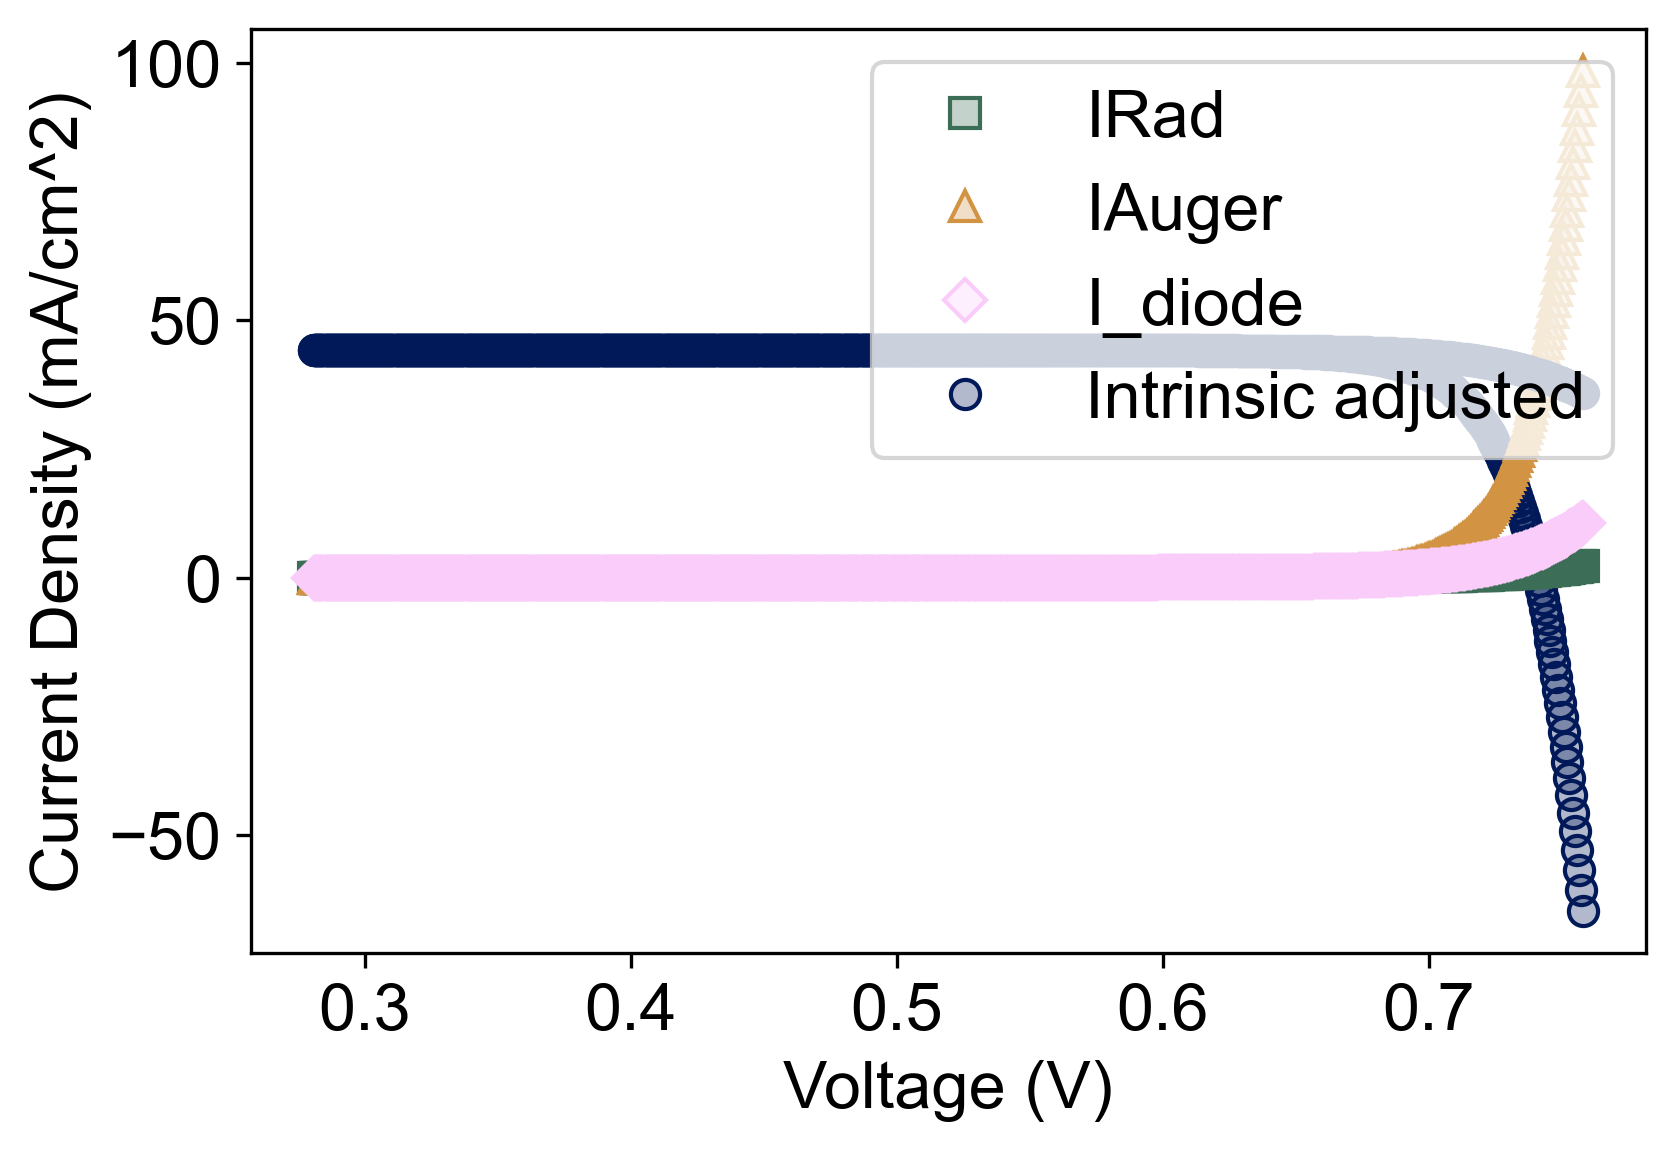

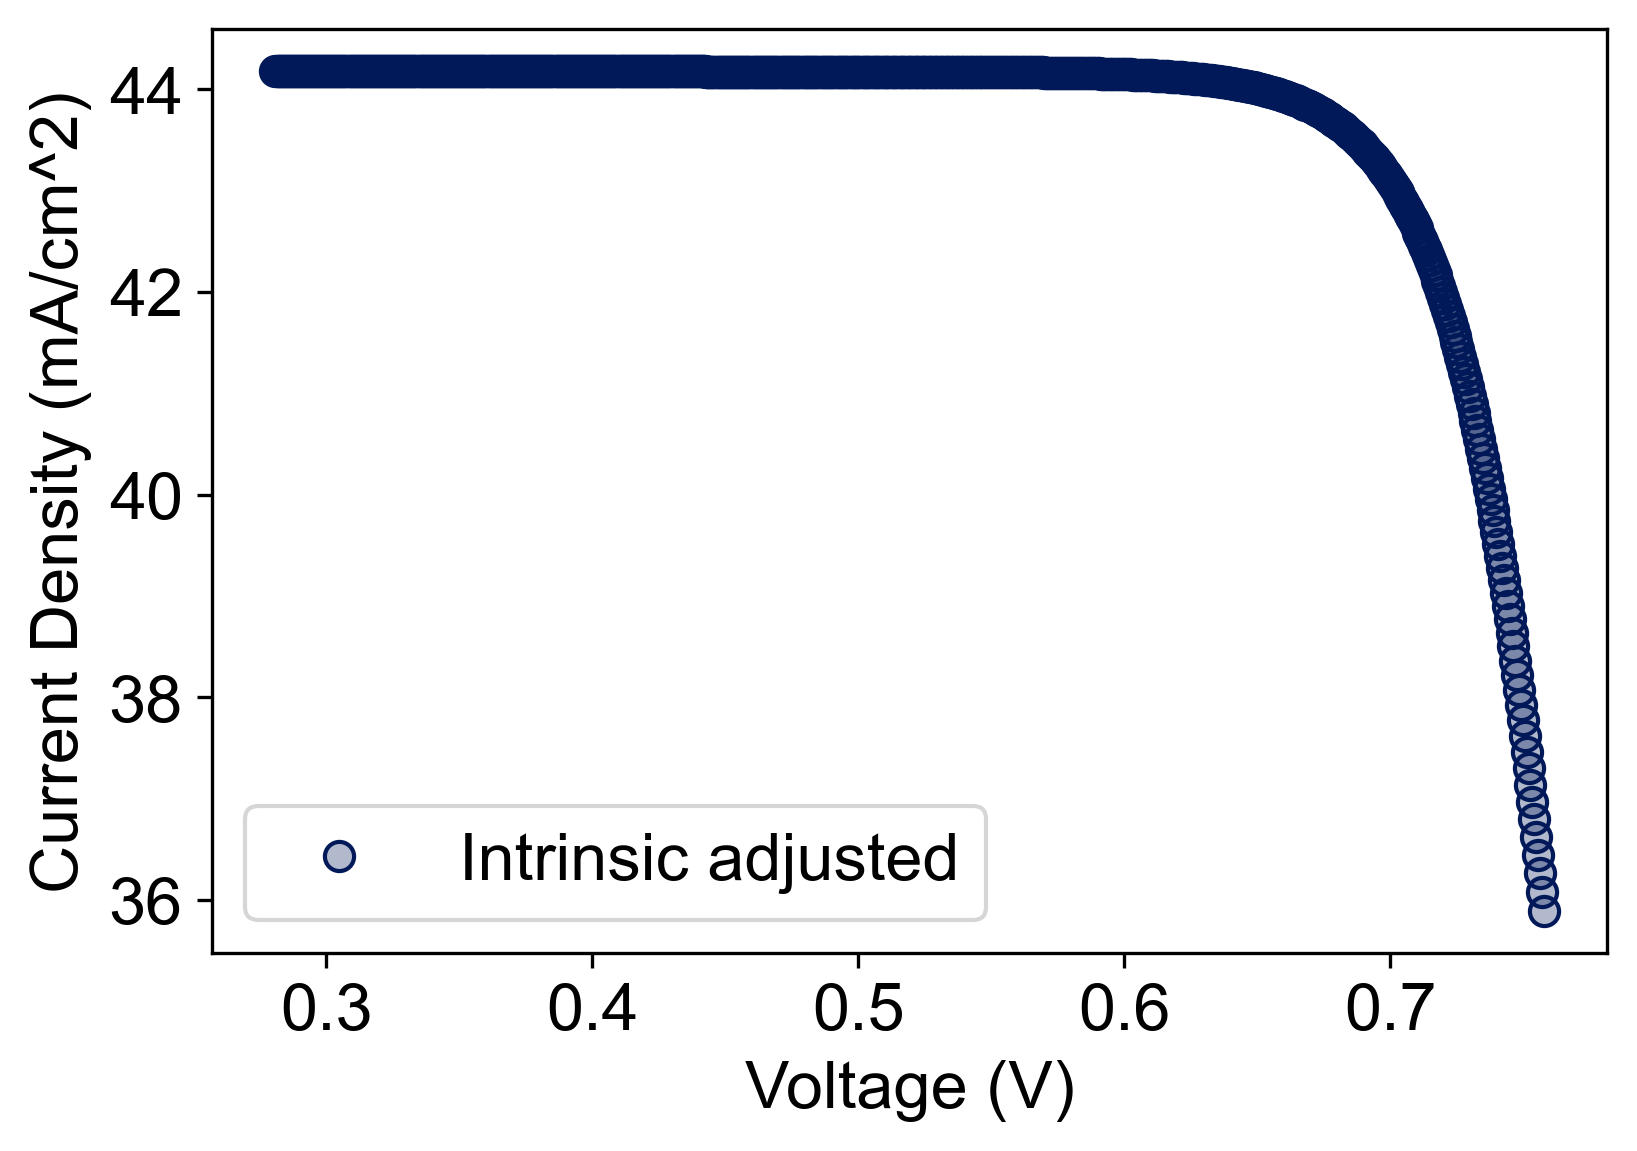

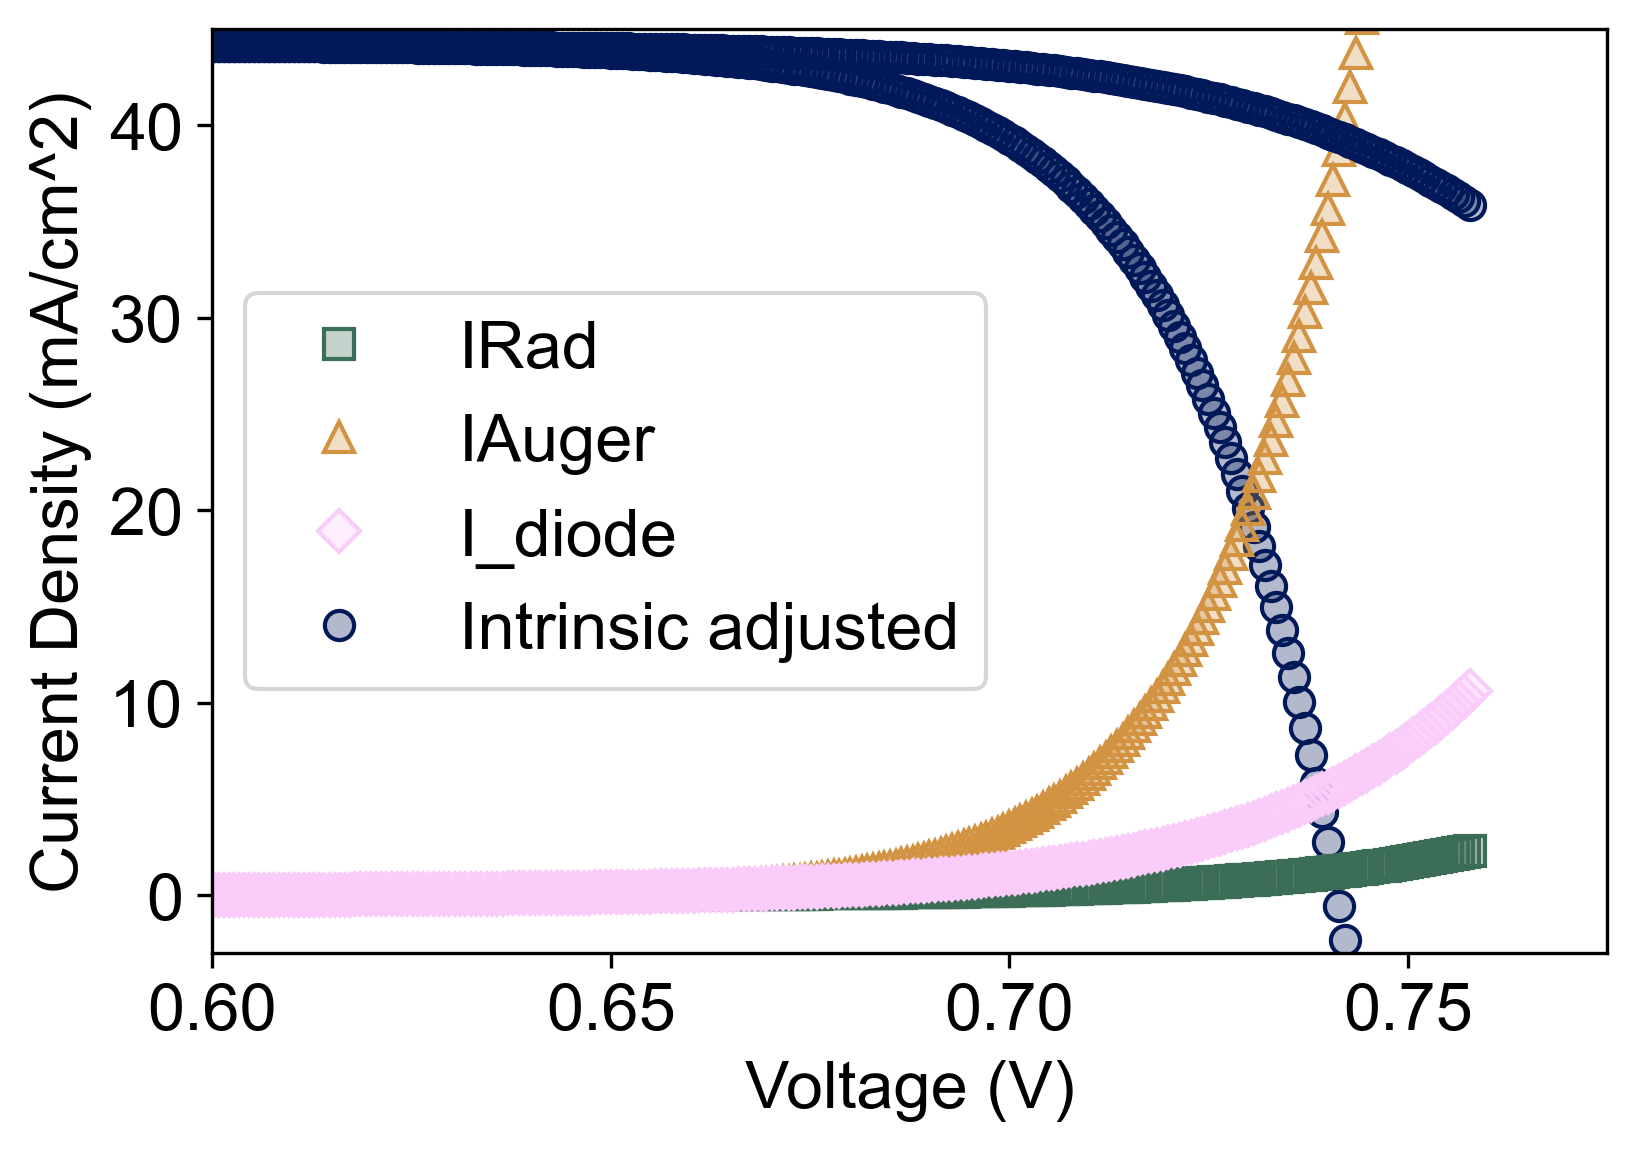

0.7577429331855281


In [13]:
# Silicon bottom cell single junction simulation
Vcell = np.linspace(-0.05, 0.74, 100)  # the voltage range for the cell simulation

# calculate the generation rates, and Jsc ( A/cm2)
Jsc_Si, AxSi = tandex.Jsc_Si_func(Waf_thick, lambda_vec, AM15g)
J0_Si = q * np.trapezoid(AxSi * BB300K, lambda_vec)
AAF = 1  # Active Area Fraction

# Re-calculate the currents, based on the optimal pitch. Units of Amperes
# silicon bottom cell
Isc_Si = -AAF * w * (l / 2) * Jsc_Si
I01_Si = w * (l / 2) * J0_Si

delta_n = np.logspace(16, 17, 200)  #
# Calculate  lifetimes
t_Aug, t_Rad, n_i_eff, _, _, _, _ = tandex.Si_bulk_lifetime(
    dop_type * Ndop, delta_n, Waf_thick, ni, T
)
tau_eff = 1 / (
    1 / t_Aug + 1 / t_Rad + (J0n_Si * (Ndop + delta_n) / (Waf_thick * q * n_i_eff**2))
)  # Combined intrinsic lifetime
rhs_Dn = Jsc_Si * tau_eff / (q * Waf_thick)  # Dn diffusion length

delta_n2 = delta_n[np.argmin(np.abs(delta_n - rhs_Dn))]
rho_Si = tandex.Si_res(delta_n2, Ndop)
RserInt = rho_Si[0] * Waf_thick  # ohms.cm^2 - internal series resistance (Si).

Rser = 0 + RserInt  # series resistivity in ohms.cm^2 [TCO + Internal]
print(f"Silicon Internal Series Resistivity = {1e3*RserInt:.2e} mOhms.cm^2")

# bottom cell parameters: Isc_Si, Rsh_Si, I01_Si, I0Aug_Si, I0d_Si, n_def
bottom_cell = [
    Isc_Si,
    Rsh_Si / (w * (l / 2)),
    I01_Si,
    J0Aug_Si * w * (l / 2),
    J0n_Si * w * (l / 2),
    1 * n_def,
]

iV, iJ, iJsc, iVoc, iFF = tandex.pseudo_efficiency_Si(
    l, Waf_thick, J0n_Si, 0, dop_type, Ndop, ni, Jsc_Si
)
voltages, currents, I_d1, I_d2, I_d3 = tandex.simulate_Si_sj(bottom_cell, Rser, w, l, iV)
eff, Jsc, Voc, FF = tandex.calculate_efficiency(voltages, currents, False)

print(
    f"MSE is: {np.sqrt(np.sum( (np.log(np.abs(currents*1e3)) - np.log(np.abs(iJ)))**2)  ):.3f}"
)

print(f"\n3-diode Si single junction including internal Rser:")
print(
    f"Efficiency= {eff:.2f}, Jsc = {1e3*Jsc:.5f} mA/cm^2, Voc = {1e3*Voc:.2f} mV, FF = {0.1*eff/(Voc*Jsc):.5f} % "
)
print(f"J0_Si = {J0_Si:.5e} A/cm^2")
print(f"J0Aug_Si = {J0Aug_Si:.5e} A/cm^2")

tandex.plot_si_jv(iV, iJ, voltages, currents, Voc, Jsc, FF, eff)

print(I_d1*1e3)

plt.plot(voltages, currents*1e3)
plt.plot(voltages, I_d1* 1e3, label="IRad")
plt.plot(voltages, I_d2* 1e3, label="IAuger")
plt.plot(voltages, I_d3* 1e3, label="I_diode")
plt.plot(voltages, currents*1e3+I_d1*1e3 + I_d2*1e3, label='Intrinsic adjusted')
plt.ylabel("Current Density (mA/cm^2)")
plt.xlabel("Voltage (V)")
plt.legend()
plt.show()

plt.plot(voltages, currents*1e3+I_d1*1e3 + I_d2*1e3, label='Intrinsic adjusted')
plt.ylabel("Current Density (mA/cm^2)")
plt.xlabel("Voltage (V)")
plt.legend()
plt.show()

plt.plot(voltages, currents*1e3)
plt.plot(voltages, I_d1* 1e3, label="IRad")
plt.plot(voltages, I_d2* 1e3, label="IAuger")
plt.plot(voltages, I_d3* 1e3, label="I_diode")
plt.plot(voltages, currents*1e3+I_d1*1e3 + I_d2*1e3, label='Intrinsic adjusted')
plt.xlim(0.6,0.775)
plt.ylim(-3,45)
plt.ylabel("Current Density (mA/cm^2)")
plt.xlabel("Voltage (V)")
plt.legend()
plt.show()

print(voltages.max())

0.0009340708908382907
0.042736402378409366 3.991882944082448e-05 0.6256410256410256 0.6256809444704665
0.0013209343634611598
0.0430593147162881 5.687852847583377e-05 0.6256410256410256 0.6256979041695014
0.0017137074899076755
0.04329176603215501 7.418942370063474e-05 0.6256410256410256 0.6257152150647263
0.0021141748700938255
0.043469542691013885 9.190221477181228e-05 0.6256410256410256 0.6257329278557975
0.0025340888436570837
0.04361122971891973 0.00011051473068888075 0.6256410256410256 0.6257515403717145
0.0029506681770592154
0.04372760809872034 0.00012902566167581094 0.6256410256410256 0.6257700513027015
0.00338071563393019
0.043825420462525244 0.00014816128412122314 0.6256410256410256 0.6257891869251468
0.003823508392447231
0.04390913625928761 0.00016788695099249519 0.6256410256410256 0.6258089125920181
0.004251731672748848
0.043981856171200207 0.0001869990509093763 0.6256410256410256 0.625828024691935
0.004688261615459626
0.04404579392036112 0.000206498204959274 0.6256410256410256

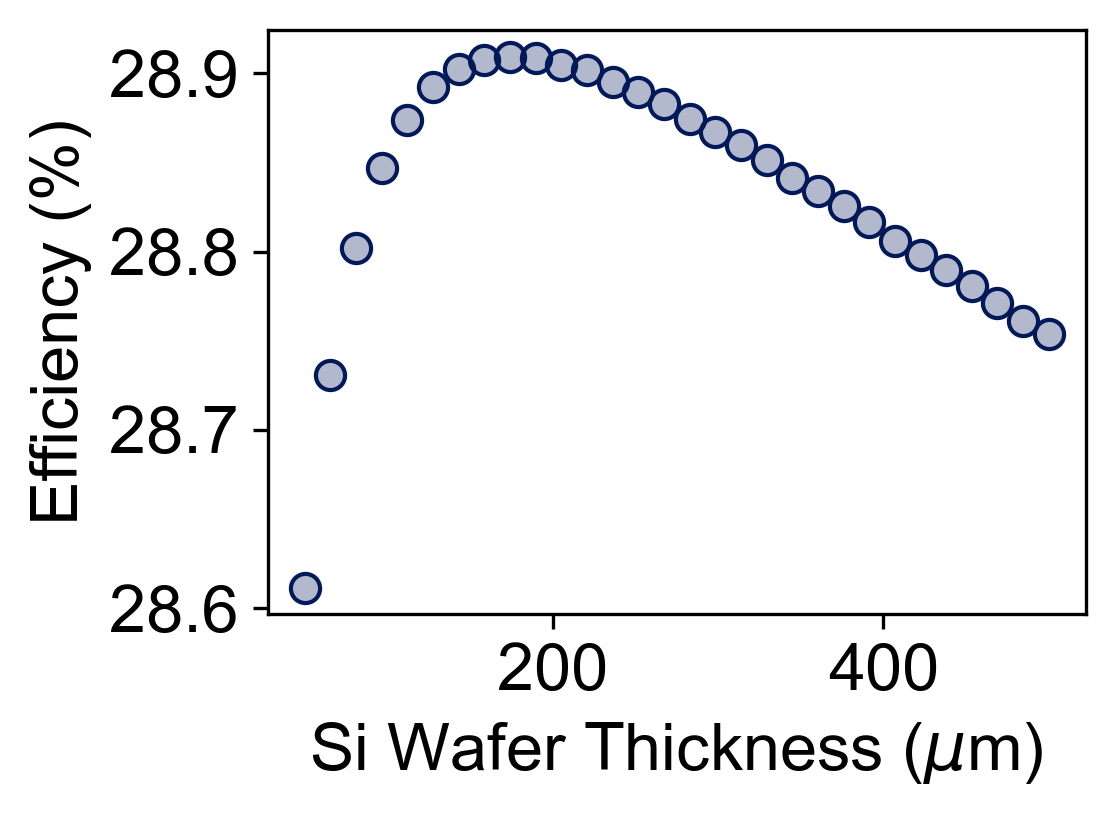

In [14]:
# Calculate Silicon efficiency vs. wafer thickness
Waf_thick_vec = np.linspace(0.005, 0.05, 30)  # 20 points from 20um to 300um

eff_vec = np.zeros_like(Waf_thick_vec)
Voc_vec = np.zeros_like(Waf_thick_vec)
Jsc_vec = np.zeros_like(Waf_thick_vec)
rho_Si = np.zeros_like(Waf_thick_vec)
delta_n2 = np.zeros_like(Waf_thick_vec)

for i, Waf_thick in enumerate(Waf_thick_vec):
    # Update Auger recombination for current thickness
    J0Aug_Si = q * C_aug * ni**3 * Waf_thick

    # Calculate generation rates and Jsc for current thickness
    Jsc_Si, AxSi = tandex.Jsc_Si_func(Waf_thick, lambda_vec, AM15g)
    J0_Si = q * np.trapezoid(AxSi * BB300K, lambda_vec)

    # Estimate series resistance for current thickness
    t_Aug, t_Rad, n_i_eff, _, _, _, _ = tandex.Si_bulk_lifetime(
        dop_type * Ndop, delta_n, Waf_thick, ni, T
    )
    tau_eff = 1 / (
        1 / t_Aug
        + 1 / t_Rad
        + (J0n_Si * (Ndop + delta_n) / (Waf_thick * q * n_i_eff**2))
    )
    rhs_Dn = Jsc_Si * tau_eff / (q * Waf_thick)
    delta_n2[i] = delta_n[np.argmin(np.abs(delta_n - rhs_Dn))]
    rho_Si2 = tandex.Si_res(delta_n2[i], Ndop)
    rho_Si[i] = rho_Si2[0]
    RserInt = rho_Si2[0] * Waf_thick
    Rser = RserInt

    # Prepare bottom cell parameters
    Isc_Si = -w * (l / 2) * Jsc_Si
    I01_Si = w * (l / 2) * J0_Si
    bottom_cell = [
        Isc_Si,
        Rsh_Si / (w * (l / 2)),
        I01_Si,
        J0Aug_Si * w * (l / 2),
        J0n_Si * w * (l / 2),
        n_def,
    ]

    # Simulate JV curve
    Vcell = np.linspace(0.6, 0.70, 40)
    voltages, currents, I_d1, I_d2, I_d3 = tandex.simulate_Si_sj(bottom_cell, Rser, w, l, Vcell)
    eff, Jsc, Voc, FF = tandex.calculate_efficiency(voltages, currents, False)

    eff_vec[i] = eff
    Voc_vec[i] = Voc
    Jsc_vec[i] = Jsc
print(
    f"Maximum Efficiency: {np.max(eff_vec):.2f} % for Si wafer thickness {Waf_thick_vec[np.argmax(eff_vec)] * 1e4:.2f} um"
)

# Plot efficiency vs. Si wafer thickness
plt.figure(figsize=(4, 3))
plt.plot(Waf_thick_vec * 1e4, eff_vec, label="Efficiency (%)")
plt.xlabel(r"Si Wafer Thickness ($\mu$m)")
plt.ylabel("Efficiency (%)")
plt.tight_layout()
plt.show()

0.0011563429342529357
0.021320874542198 2.4654242628963953e-05 0.6256410256410256 0.6256656798836546
0.0015792752055760302
0.02147983297902556 3.392256764368938e-05 0.6256410256410256 0.6256749482086693
0.002015273023688551
0.021593625248328863 4.351705044659714e-05 0.6256410256410256 0.6256845426914722
0.002457235887022948
0.02168013006041747 5.32731936197828e-05 0.6256410256410256 0.6256942988346454
0.002914274911455122
0.021748630116462664 6.338148710692443e-05 0.6256410256410256 0.6257044071281326
0.0033687287235934327
0.02180450829177971 7.345347338634949e-05 0.6256410256410256 0.625714479114412
0.00383362382974984
0.02185113101890579 8.376901658106313e-05 0.6256410256410256 0.6257247946576067
0.004330834855344641
0.021890726443558606 9.480512109057824e-05 0.6256410256410256 0.6257358307621163
0.004960652094609194
0.02192482603764745 0.00010876143420759802 0.6256410256410256 0.6257497870752332
0.0056220726445473665
0.0219545472504592 0.00012343005952022927 0.6256410256410256 0.625

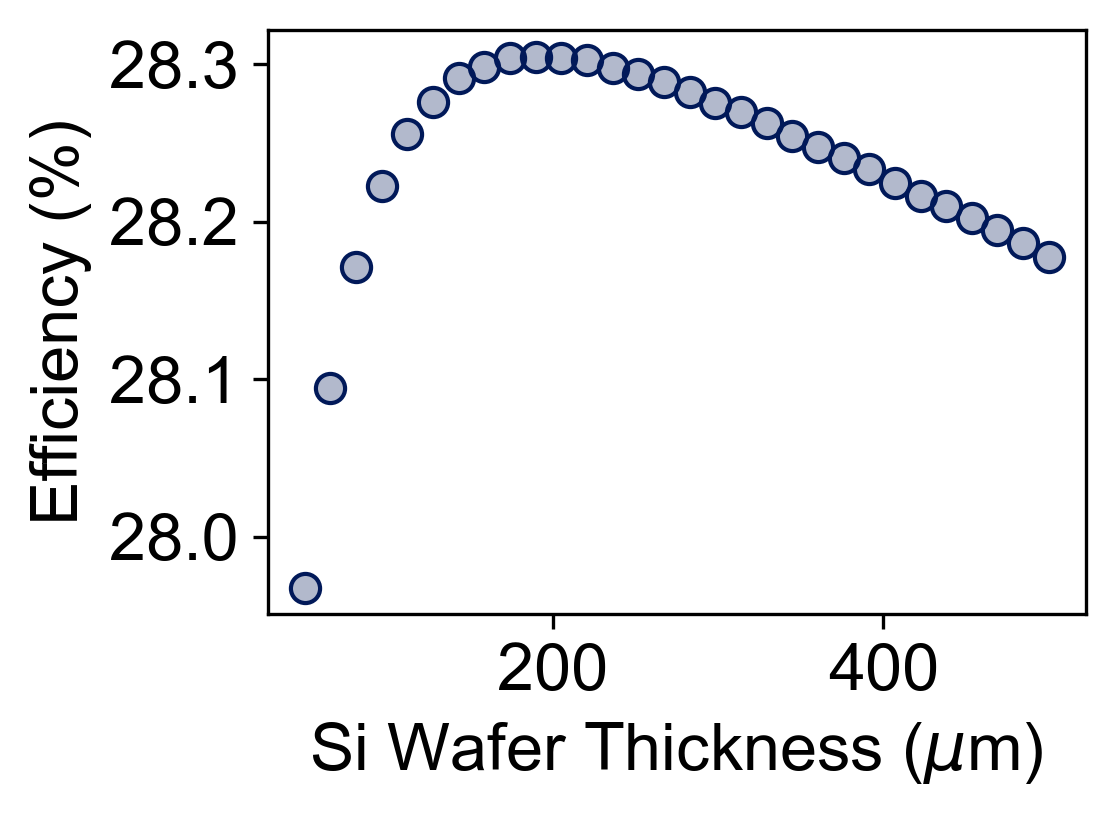

In [15]:
# Calculate Silicon efficiency vs. wafer thickness [this time for the half Jsc in tandem]
Waf_thick_vec = np.linspace(0.005, 0.05, 30)  # 20 points from 20um to 300um

eff_vec = np.zeros_like(Waf_thick_vec)
Voc_vec = np.zeros_like(Waf_thick_vec)
Jsc_vec = np.zeros_like(Waf_thick_vec)
rho_Si = np.zeros_like(Waf_thick_vec)
delta_n2 = np.zeros_like(Waf_thick_vec)

for i, Waf_thick in enumerate(Waf_thick_vec):
    # Update Auger recombination for current thickness
    J0Aug_Si = q * C_aug * ni**3 * Waf_thick

    # Calculate generation rates and Jsc for current thickness
    Jsc_Si, AxSi = tandex.Jsc_Si_func(
        Waf_thick, lambda_vec, AM15g / 2 
    )  # this is the change
    J0_Si = q * np.trapezoid(AxSi * BB300K, lambda_vec)

    # Estimate series resistance for current thickness
    t_Aug, t_Rad, n_i_eff, _, _, _, _ = tandex.Si_bulk_lifetime(
        dop_type * Ndop, delta_n, Waf_thick, ni, T
    )
    tau_eff = 1 / (
        1 / t_Aug
        + 1 / t_Rad
        + (J0n_Si * (Ndop + delta_n) / (Waf_thick * q * n_i_eff**2))
    )
    rhs_Dn = Jsc_Si * tau_eff / (q * Waf_thick)
    delta_n2[i] = delta_n[np.argmin(np.abs(delta_n - rhs_Dn))]
    rho_Si2 = tandex.Si_res(delta_n2[i], Ndop)
    rho_Si[i] = rho_Si2[0]
    RserInt = rho_Si2[0] * Waf_thick
    Rser = RserInt

    # Prepare bottom cell parameters
    Isc_Si = -w * (l / 2) * Jsc_Si
    I01_Si = w * (l / 2) * J0_Si
    bottom_cell = [
        Isc_Si,
        Rsh_Si / (w * (l / 2)),
        I01_Si,
        J0Aug_Si * w * (l / 2),
        J0n_Si * w * (l / 2),
        n_def,
    ]

    # Simulate JV curve
    Vcell = np.linspace(0.6, 0.70, 40)
    voltages, currents, I_d1, I_d2, I_d3 = tandex.simulate_Si_sj(bottom_cell, Rser, w, l, Vcell)
    eff, Jsc, Voc, FF = tandex.calculate_efficiency(voltages, currents, False)

    eff_vec[i] = eff * 2
    Voc_vec[i] = Voc
    Jsc_vec[i] = Jsc
print(
    f"Maximum Efficiency: {np.max(eff_vec):.2f} % for Si wafer thickness {Waf_thick_vec[np.argmax(eff_vec)] * 1e4:.2f} um with 1/2 of the Jsc [tandem case]"
)
print(f"Maximum Jsc: {Jsc_vec[np.argmax(eff_vec)] * 1e3:.2f} mA/cm2 [tandem case]")

# Plot efficiency vs. Si wafer thickness
plt.figure(figsize=(4, 3))
plt.plot(Waf_thick_vec * 1e4, eff_vec, label="Efficiency (%)")
plt.xlabel(r"Si Wafer Thickness ($\mu$m)")
plt.ylabel("Efficiency (%)")
plt.tight_layout()
plt.show()

## <mark> Mikael questions </mark>

- why do we do `Jsc_Si, AxSi = tandex.Jsc_Si_fun(Waf_thick, lambda_vec, AM15g/2)`? That is, why `AM15g/2` instead of `FilteredAM15g`?


## Integrated Optical-Electrical Simulation

This uses the Tranfer Matrix Method (TMM) to calculate the full optical solution of a solar cell stack.

TMM algorithm borrowed from: https://web.stanford.edu/group/mcgehee/transfermatrix/index.html, G. F. Burkhard, E. T. Hoke, M. D. McGehee, Adv. Mater., 22, 3293.


## <mark> Mikael notes</mark>

Read that


Weighted Average Transmittance into the Si: 50.68 %
Weighted Average Absorption in PVK: 39.76 %
Weighted Average Reflection: 6.26 %
Jsc_pvk = 20.79224 mA/cm^2
Jsc_Si = 19.60884 mA/cm^2


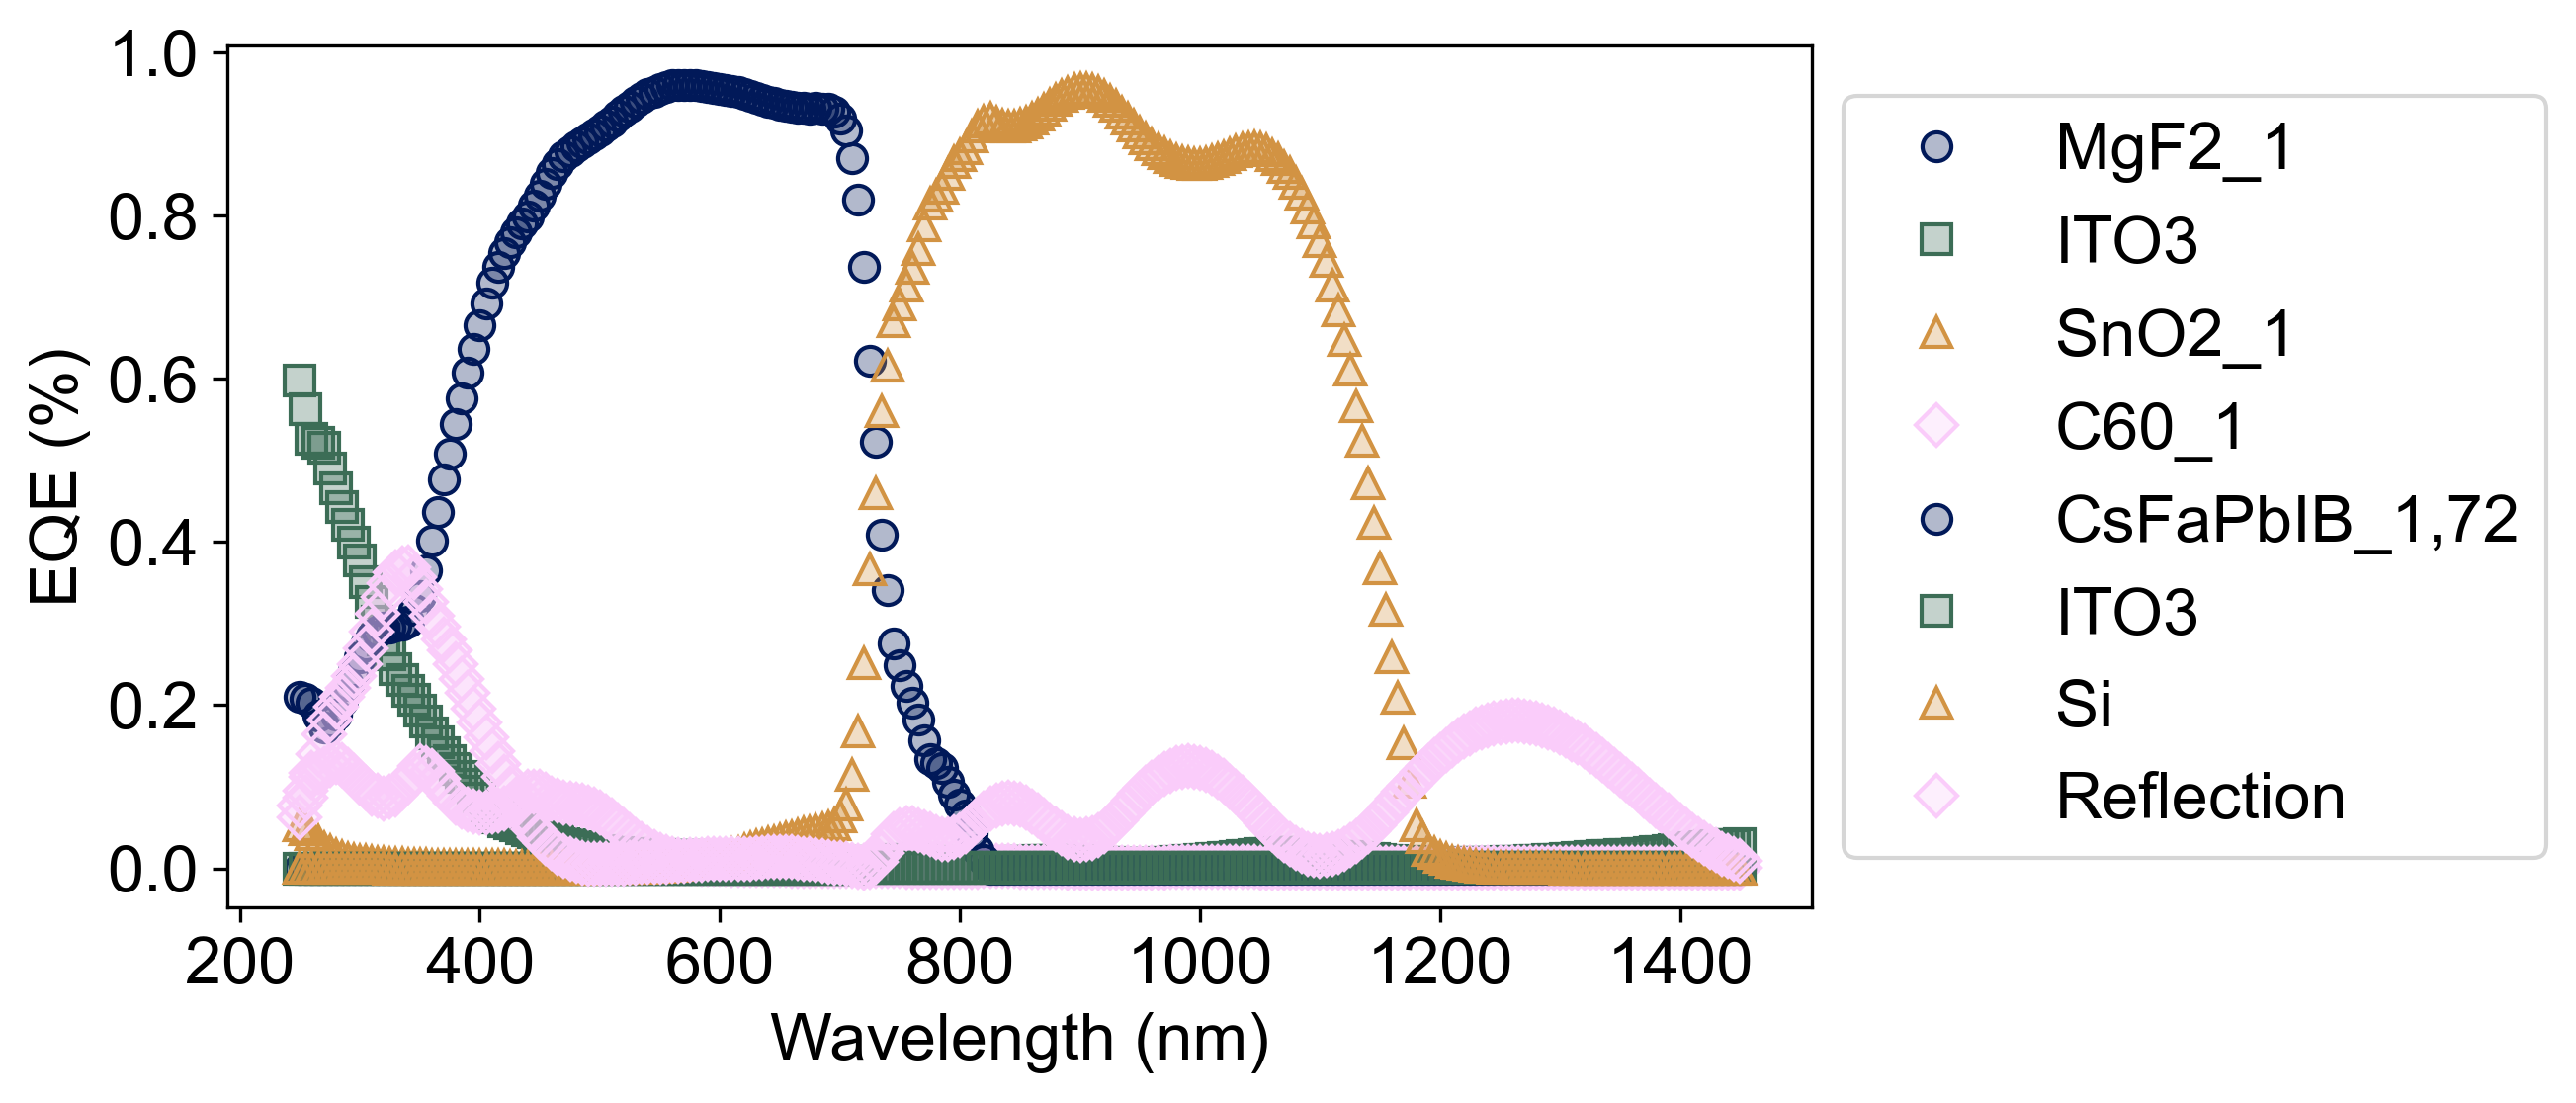

In [16]:
# we begin with the optical simulation of the tandem cell stack
AM15g_spectrum = np.load(
    "./data/AM15g_spectrum.npz"
)  # a numpy file with AM1.5g spectrum

Si_Waf_thick = 0.019  # cm
pvk_thick = 850e-7  # cm
TCE_thick = 40e-7  # cm
TCE_rho = 0.42e-3  # Ω·cm, example value for TCO

layers = ["Air", "MgF2_1", "ITO3", "SnO2_1", "C60_1", "CsFaPbIB_1,72", "ITO3", "Si_"]
thicknesses = np.array(
    [0, 115, TCE_thick * 1e7, 20, 10, pvk_thick * 1e7, 2, 5000]
)  # (nm)
# ignore the Si thickness, 1um only for calculating the Pvk.

pvk_layer_id = 5  # indexing starts from 0

lambda_start = (
    250  # build a wavelength range to calculate over, starting wavelength (nm)
)
lambda_stop = 1450  # final wavelength (nm)
lambda_step = 5  # wavelength step size

x_step = 1  # grid spacing of device cross section simulation in nm

lambda_vec = np.arange(
    lambda_start, lambda_stop + lambda_step, lambda_step, float
)  # wavelength range in nm
AM15g = np.interp(
    lambda_vec, AM15g_spectrum["LambdaVar"], AM15g_spectrum["AM15gFlux"]
)  #  nm , s^-1*cm^-2*nm^-1

front_layers = np.arange(0, 6)  # layers in front of silicon layer

# obtain the complex refractive index for all layers from the excel database
excel_path = "./data/Optical_Properties.xlsx"
df_nk_excel = pd.read_excel(excel_path, header=0, sheet_name=0)
n_k = np.zeros((len(layers), len(lambda_vec)), dtype=complex)

# load index of refraction for each material in the stack, in the variable n_k
for i, l in enumerate(layers):
    n_k_i = np.array(tandex.get_ntotal_from_excel(l, lambda_vec, df_nk_excel))
    n_k[i, :] = n_k_i

# correct the n_k values to account for the exact bangap in the pvk_layer
df_pvk_tmm = pd.DataFrame(columns=df_pvk0.columns)
df_pvk_tmm["lambda_k"] = lambda_vec
df_pvk_tmm["alpha"] = (4 * np.pi * n_k[pvk_layer_id, :].imag) / (lambda_vec * 1e-7)
lambda_shift = tandex.get_lambda_shift(EgapP, lambda_vec, df_pvk_tmm)
int_n = interp1d(
    lambda_vec + lambda_shift,
    n_k[pvk_layer_id, :].real,
    kind="linear",
    bounds_error=False,
    fill_value="extrapolate",
)
int_k = interp1d(
    lambda_vec + lambda_shift,
    n_k[pvk_layer_id, :].imag,
    kind="linear",
    bounds_error=False,
    fill_value="extrapolate",
)
new_n_k = np.array(
    [complex(n, k) for n, k in zip(int_n(lambda_vec), int_k(lambda_vec))]
)
n_k[pvk_layer_id, :] = new_n_k

# TMM_Tx_Ax returns Absorption as [layer, wavelength], Reflection as [wavelength]
TotalTx, Absorption, Reflection, E, x_pos, n = tandex.TMM_Tx_Ax(
    layers, thicknesses, lambda_vec, x_step, front_layers, n_k
)

WAT = np.dot(AM15g, TotalTx) / np.sum(AM15g)
print(f"Weighted Average Transmittance into the Si: {100*WAT:.2f} %")
print(
    f"Weighted Average Absorption in PVK: {100*np.sum(AM15g*Absorption[pvk_layer_id,:])/np.sum(AM15g):.2f} %"
)
print(
    f"Weighted Average Reflection: {100*np.sum(AM15g*Reflection)/np.sum(AM15g):.2f} %"
)

Jsc_pvk = q * np.trapezoid(AM15g * Absorption[pvk_layer_id, :], lambda_vec)  # A/cm2
print(f"Jsc_pvk = {Jsc_pvk*1e3:.5f} mA/cm^2")

# Plot normalized intensity absorbed / cm3-nm at each layer and wavelength
fig2 = plt.figure(figsize=(9, 4))
ax2 = fig2.add_subplot(111)
ax2.set_xlabel("Wavelength (nm)")
ax2.set_ylabel("EQE (%)")


for matind in range(1, len(layers) - 1):
    ax2.plot(lambda_vec, Absorption[matind, :], label=layers[matind])

EQE_pvk = Absorption[pvk_layer_id, :] # External quantum efficiency of the perovskite without any electrical losses

# Silicon absorption and Jsc are calculated via Green's model for lambertian absorption
FilteredAM15g = AM15g * TotalTx  # Filtered AM15g spectrum after the top cell
Jsc_Si, AxSi = tandex.Jsc_Si_func(Si_Waf_thick, lambda_vec, FilteredAM15g)
EQE_Si = FilteredAM15g * AxSi / AM15g # External quantum efficiency of the silicon without any electrical losses

print(f"Jsc_Si = {1e3*Jsc_Si:.5f} mA/cm^2")

ax2.plot(lambda_vec, EQE_Si, label="Si")
ax2.plot(lambda_vec, Reflection, label="Reflection")
ax2.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), ncol=1, borderaxespad=0)
plt.tight_layout()
plt.show()

## <mark> Mikael notes </mark>
No electrical losses here for EQE -- just optical. So actually a plot of normalized intensity absorbed / cm3-nm at each layer and wavelength

Optimal pitch l = 0.162 cm
top cell parameters
Isc_pvk []: -0.0003323
Rsh_pvk []: 1.2e+07
I0_pvk + I01d_pvk []: 1.6481e-25
I0def_pvk []: 4.8545e-25
Rdef_pvk []: 741.57
I02_pvk []: 3.3982e-15
bottom cell parameters
Isc_Si []: -0.00031
Rsh_Si []: 3089887.64
I01_Si []: 6.518e-18
I0Aug_Si []: 3.4306e-22
I0n_Si []: 3.2364e-17
n_def []: 1
1.7338198347107436
0.0003133166769968647 0.0005432346691228234 0.1772727272727273 0.17781596194185012
Maximum Efficiency: 33.28 %
Jsc: 19.39 mA/cm^2
Voc: 1.96 V
FF: 0.88


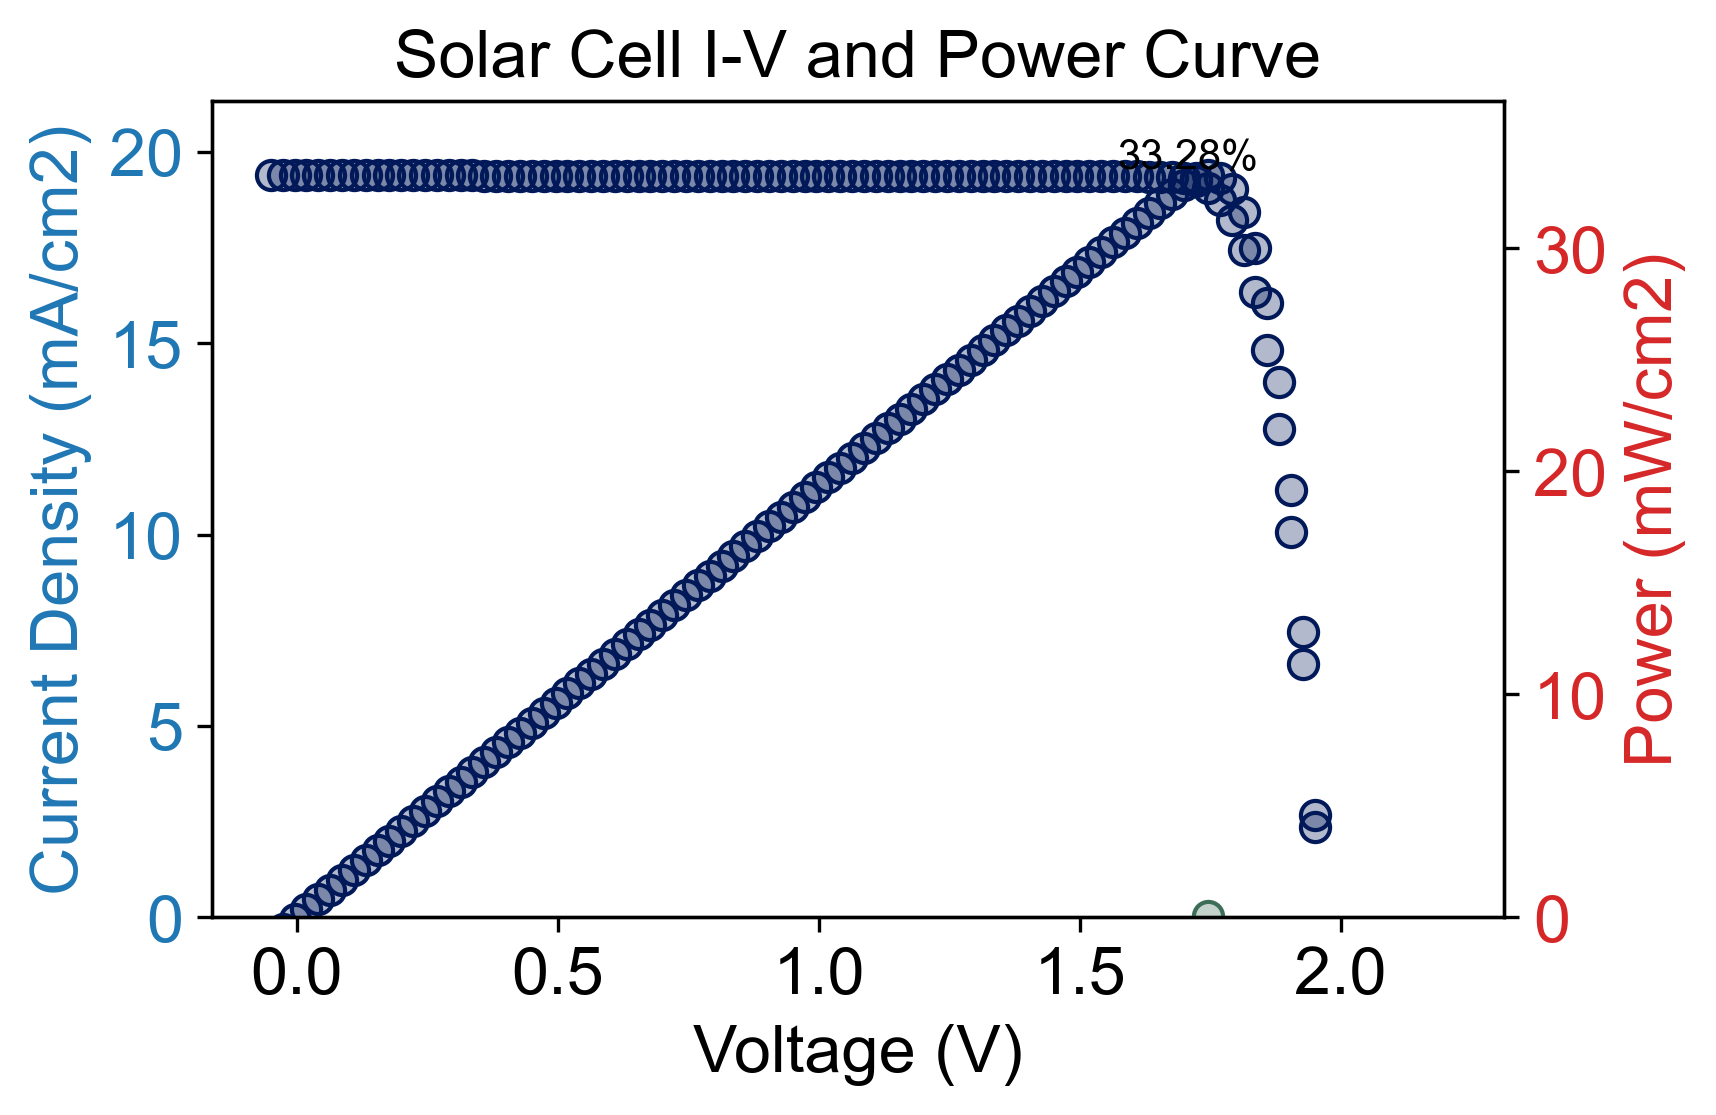

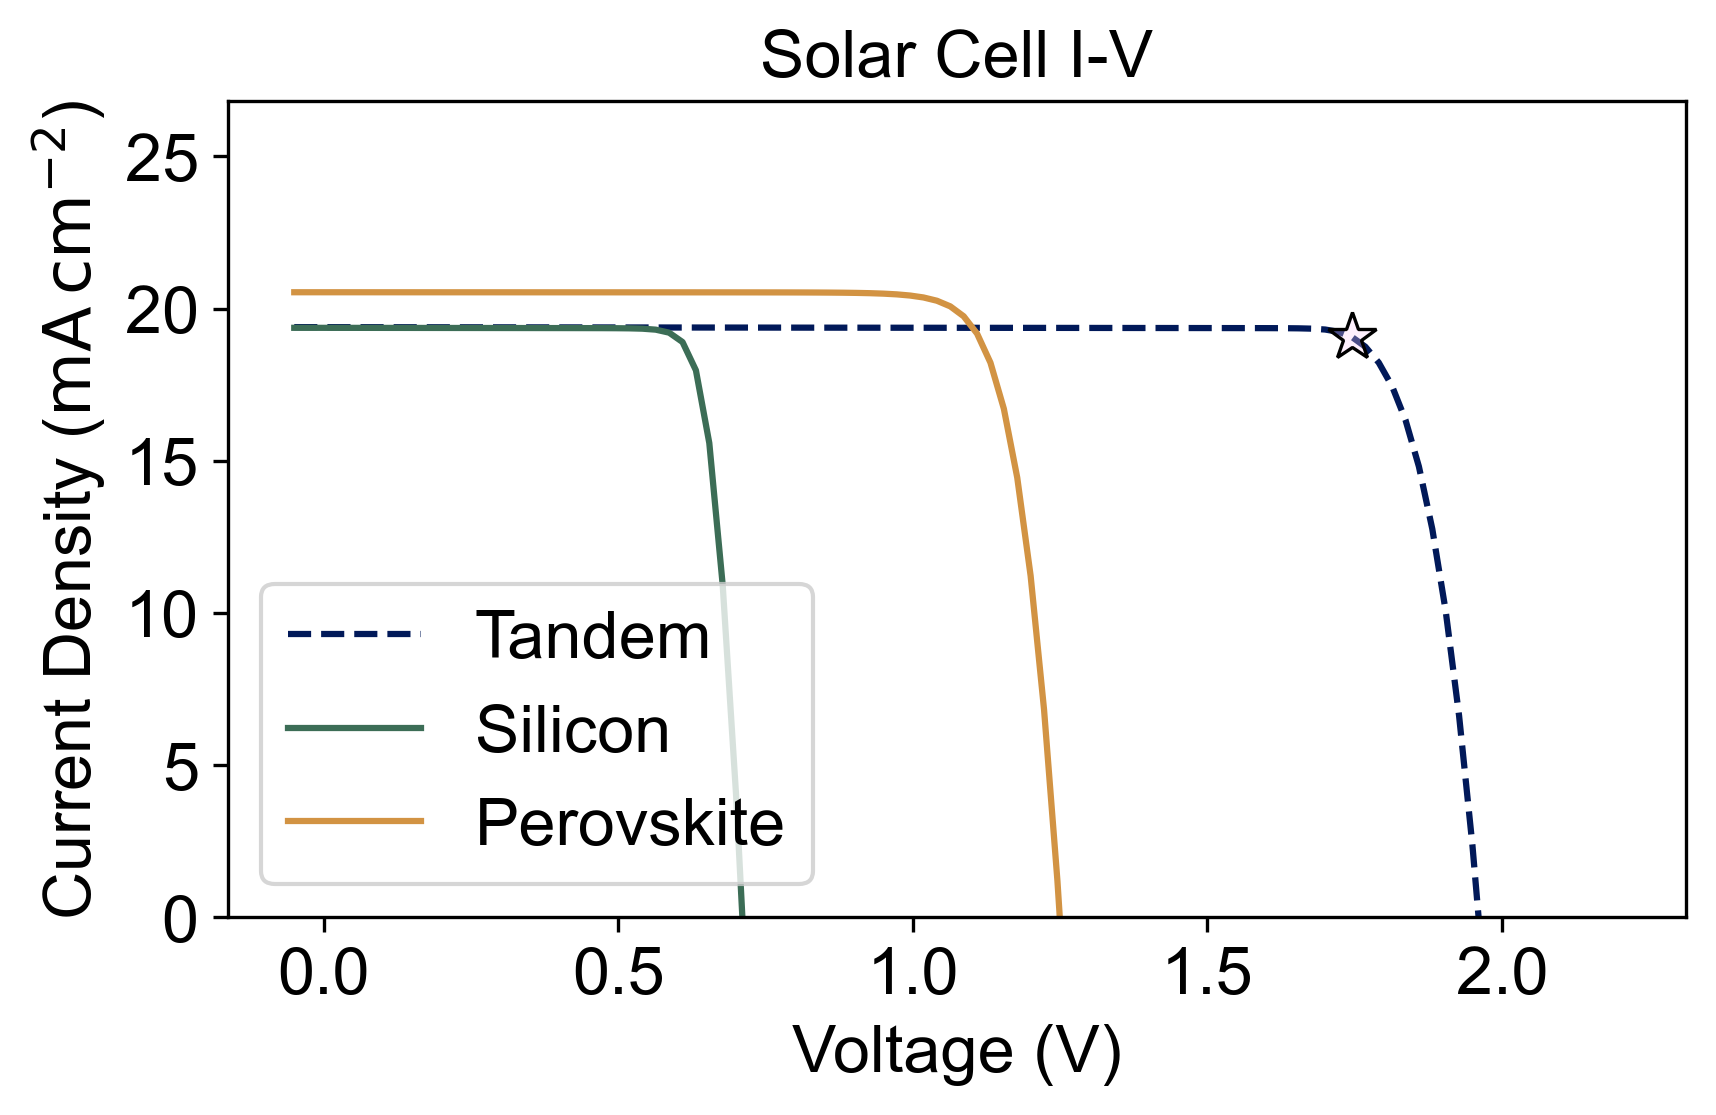

In [17]:
# Electrical simulation

R_tco = TCE_rho / (TCE_thick)  # TCO sheet resistance (Ω/sq)

# combined series resistance from internal factors
RserInt = 1.5 + 4.7e-3  # ohms.cm2 - internal series resistance (pvk + Si).

# Black body spectrum at 300K temperature
BB300K = (
    2 * np.pi * c / ((lambda_vec * 1e-9) * lambda_vec * (lambda_vec * 1e-7) ** 2)
) * (1.0 / (np.exp(hc / (lambda_vec * Vt)) - 1))

w = 0.2  # Unit cell dimensions (cm)
d = 20e-4  # Contact width in cm
l_values = np.linspace(
    0.02, 0.8, 100
)  # range of values to extract optimal pitch l (cm)

Vcell = np.linspace(-0.05, 2.2, 100)  # the voltage range for the cell simulation

J0_pvk = q * np.trapezoid(BB300K * EQE_pvk, lambda_vec)
J0_Si = q * np.trapezoid(BB300K * EQE_Si, lambda_vec)

AAF = 1 - d / l_values  # Active Area Fraction, assuming d = 20 um contact width
l, _, _, _, _ = tandex.find_optimal_pitch(
    J0_Si, J0n_Si, J0Aug_Si, Rsh_Si, Jsc_Si, l_values, R_tco, AAF
)
print(f"Optimal pitch l = {l:.3f} cm")
AAF = 1 - d / l

# Re-calculate the currents, based on the optimal pitch. Units of Amperes
# perovskite top cell
Isc_pvk = -AAF * w * (l / 2) * Jsc_pvk
I0_pvk = w * (l / 2) * J0_pvk
I01d_pvk = (w * (l / 2)) * J01d_pvk

# silicon bottom cell
Isc_Si = -AAF * w * (l / 2) * Jsc_Si
I01_Si = w * (l / 2) * J0_Si

Rser = (
    R_tco * (l**2 / (12)) + RserInt
)  # series resistance in ohms.cm^2 [TCO + external]

# top cell parameters: Isc_pvk, Rsh_pvk, I0_pvk, I0def_pvk, Rdef_pvk, I02_pvk
top_cell = [
    Isc_pvk,
    Rsh_pvk / (w * (l / 2)),
    I0_pvk + I01d_pvk,
    J0def_pvk * w * (l / 2),
    Rdef_pvk / (w * (l / 2)),
    J02_pvk * w * (l / 2),
]
# bottom cell parameters: Isc_Si, Rsh_Si, I01_Si, I0Aug_Si, I0d_Si, n_def
bottom_cell = [
    Isc_Si,
    Rsh_Si / (w * (l / 2)),
    I01_Si,
    J0Aug_Si * w * (l / 2),
    J0n_Si * w * (l / 2),
    n_def,
]

print('top cell parameters')
print(f"Isc_pvk []: {top_cell[0]:.5g}")
print(f"Rsh_pvk []: {top_cell[1]:.2g}")
print(f"I0_pvk + I01d_pvk []: {top_cell[2]:.5g}")
print(f"I0def_pvk []: {top_cell[3]:.5g}")
print(f"Rdef_pvk []: {top_cell[4]:.2f}")
print(f"I02_pvk []: {top_cell[5]:.5g}")

print('bottom cell parameters')
print(f"Isc_Si []: {bottom_cell[0]:.5f}")
print(f"Rsh_Si []: {bottom_cell[1]:.2f}")
print(f"I01_Si []: {bottom_cell[2]:.5g}")
print(f"I0Aug_Si []: {bottom_cell[3]:.5g}")
print(f"I0n_Si []: {bottom_cell[4]:.5g}")
print(f"n_def []: {bottom_cell[5]:.5g}")



voltages_Si, currents_Si, _,_,_ = tandex.simulate_Si_sj(bottom_cell, Rser, w, l, Vcell)
voltages_pvk, currents_pvk = tandex.simulate_pvk_sj(top_cell, Rser, w, l, Vcell)
voltages_tandem, currents_tandem = tandex.simulate_circuit(top_cell, bottom_cell, Rser, w, l, Vcell)

import RSVoltageRestricted as fit_Ifree


eff, Jsc, Voc, FF = tandex.calculate_efficiency(voltages_tandem, currents_tandem, False)

print(f"Maximum Efficiency: {eff:.2f} %")
print(f"Jsc: {Jsc*1e3:.2f} mA/cm^2")
print(f"Voc: {Voc:.2f} V")
print(f"FF: {FF:.2f}")
eff, Jsc, Voc, FF = tandex.calculate_efficiency(voltages_tandem, currents_tandem, True)



Impp_tandem, Vmpp_tandem, _ = fit_Ifree.findMpp(voltages_tandem, currents_tandem)
Impp_Si, Vmpp_Si, _ = fit_Ifree.findMpp(voltages_Si, currents_Si)
Impp_pvk, Vmpp_pvk, _ = fit_Ifree.findMpp(voltages_pvk, currents_pvk)

fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.set_xlabel("Voltage (V)")
#plt.ylabel(r"Photon Flux Density ($\mathrm{s^{-1}\,cm^{-2}\,nm^{-1}}$)")
ax1.set_ylabel(r"Current Density ($\mathrm{mA\,cm^{-2}}$)")
ax1.plot(voltages_tandem, currents_tandem * 1e3, label="Current", linestyle="--", markersize=0)
ax1.plot(voltages_Si, currents_Si * 1e3, label="Current", linestyle="-", markersize=0)
ax1.plot(voltages_pvk, currents_pvk * 1e3, label="Current", linestyle="-", markersize=0)
ax1.tick_params(axis="y")
ax1.set_ylim(0, np.max(currents * 1e3) * 1.2)

ax1.plot(Vmpp_tandem, Impp_tandem*1000,
        marker='*', linestyle='None',
        markersize=12,
        markeredgecolor='black',
        markeredgewidth=0.8,
        label='MPP_tandem')
#ax1.plot(Vmpp_Si, Impp_Si*1000,
       # marker='*', linestyle='None',
       # markersize=12,
       # markeredgecolor='black',
       # markeredgewidth=0.8,
       # label='MPP_Si')
#ax1.plot(Vmpp_pvk, Impp_pvk*1000,
        #marker='*', linestyle='None',
        #markersize=12,
        #markeredgecolor='black',
        #markeredgewidth=0.8,
        #label='MPP_pvk')


plt.title("Solar Cell I-V")
plt.legend(["Tandem", "Silicon", "Perovskite"])
fig.tight_layout()
plt.show()

## Routine to optimise Perovskite Bandgap and Thicknesses:


In [18]:
# Define ranges for Si wafer thickness and perovskite thickness (in cm)
Si_waf_thick = 0.019
# series resistance for Si current thickness
t_Aug, t_Rad, n_i_eff, _, _, _, _ = tandex.Si_bulk_lifetime(
    dop_type * Ndop, delta_n, Si_waf_thick, ni, T
)
tau_eff = 1 / (
    1 / t_Aug
    + 1 / t_Rad
    + (J0n_Si * (Ndop + delta_n) / (Si_waf_thick * q * n_i_eff**2))
)
rhs_Dn = Jsc_Si * tau_eff / (q * Si_waf_thick)
delta_n2 = delta_n[np.argmin(np.abs(delta_n - rhs_Dn))]
rho_Si = tandex.Si_res(delta_n2, Ndop)
RserSi = rho_Si[0] * Si_waf_thick
RserInt = RserSi

# Update bottom cell density parameters for current Si thickness
J0Aug_Si = q * C_aug * ni**3 * Si_waf_thick
bottom_cell_density = np.array([Jsc_Si, Rsh_Si, J0_Si, J0Aug_Si, J0n_Si, n_def])

# TCO properties
TCE_thick = 50e-7  # cm
TCE_rho = 0.42e-3  # Ω·cm, example value for TCO
R_tco = TCE_rho / (TCE_thick)  # TCO sheet resistance (Ω/sq)

# pvk properties
pvk_thick_vec = np.linspace(500e-7, 1200e-7, 22)  # e.g., 500nm to 1200nm
pvk_Egap_vec = np.linspace(1.60, 1.75, 20)  #  eV
top_cell_density = np.array(
    [Jsc_pvk, Rsh_pvk, J01d_pvk, J0def_pvk, Rdef_pvk, J02_pvk]
)  # get re-writen

# layers defintions and thicknesses
layers = ["Air", "MgF2_1", "ITO3", "SnO2_1", "C60_1", "CsFaPbIB_1,72", "ITO3", "Si_"]
thicknesses = np.array(
    [0, 120, TCE_thick * 1e7, 20, 10, pvk_thick * 1e7, 2, 5000]
)  # (nm)

delta_n = np.logspace(15, 17, 200)  #
Vcell = np.linspace(1.5, 1.9, 100)  # the voltage range for the cell simulation
eff_map = np.zeros((len(pvk_Egap_vec), len(pvk_thick_vec)))

for i, pvk_Egap in enumerate(pvk_Egap_vec):
    for j, pvk_thick in enumerate(pvk_thick_vec):
        # Update thicknesses array for current pvk and Si thickness
        thicknesses[pvk_layer_id] = pvk_thick * 1e7  # pvk in nm

        # Run the optical-electronic efficiency calculation [this function executes the whole of methods above]
        eff, *_ = tandex.optic_electronic_efficiency(
            Si_waf_thick,
            pvk_layer_id,
            R_tco,
            BB300K,
            layers,
            thicknesses,
            lambda_vec,
            AM15g,
            x_step,
            l_values,
            front_layers,
            top_cell_density,
            bottom_cell_density,
            w,
            d,
            Vcell,
            RserInt,
            df_pvk0,
            pvk_Egap,
        )
        eff_map[i, j] = eff

# print(f"Maximum Efficiency: {np.max(eff_map):.2f} % at Bandgap  {pvk_Egap_vec[np.argmax(eff_map)] :.2f} um and pvk thickness {pvk_thick_vec[np.argmax(eff_map)] * 1e7:.2f} nm")
print(f"Maximum Efficiency: {np.max(eff_map):.2f}")

Maximum Efficiency: 33.90


Maximum efficiency at: Thickness = 766.7 nm, Bandgap = 1.695 eV


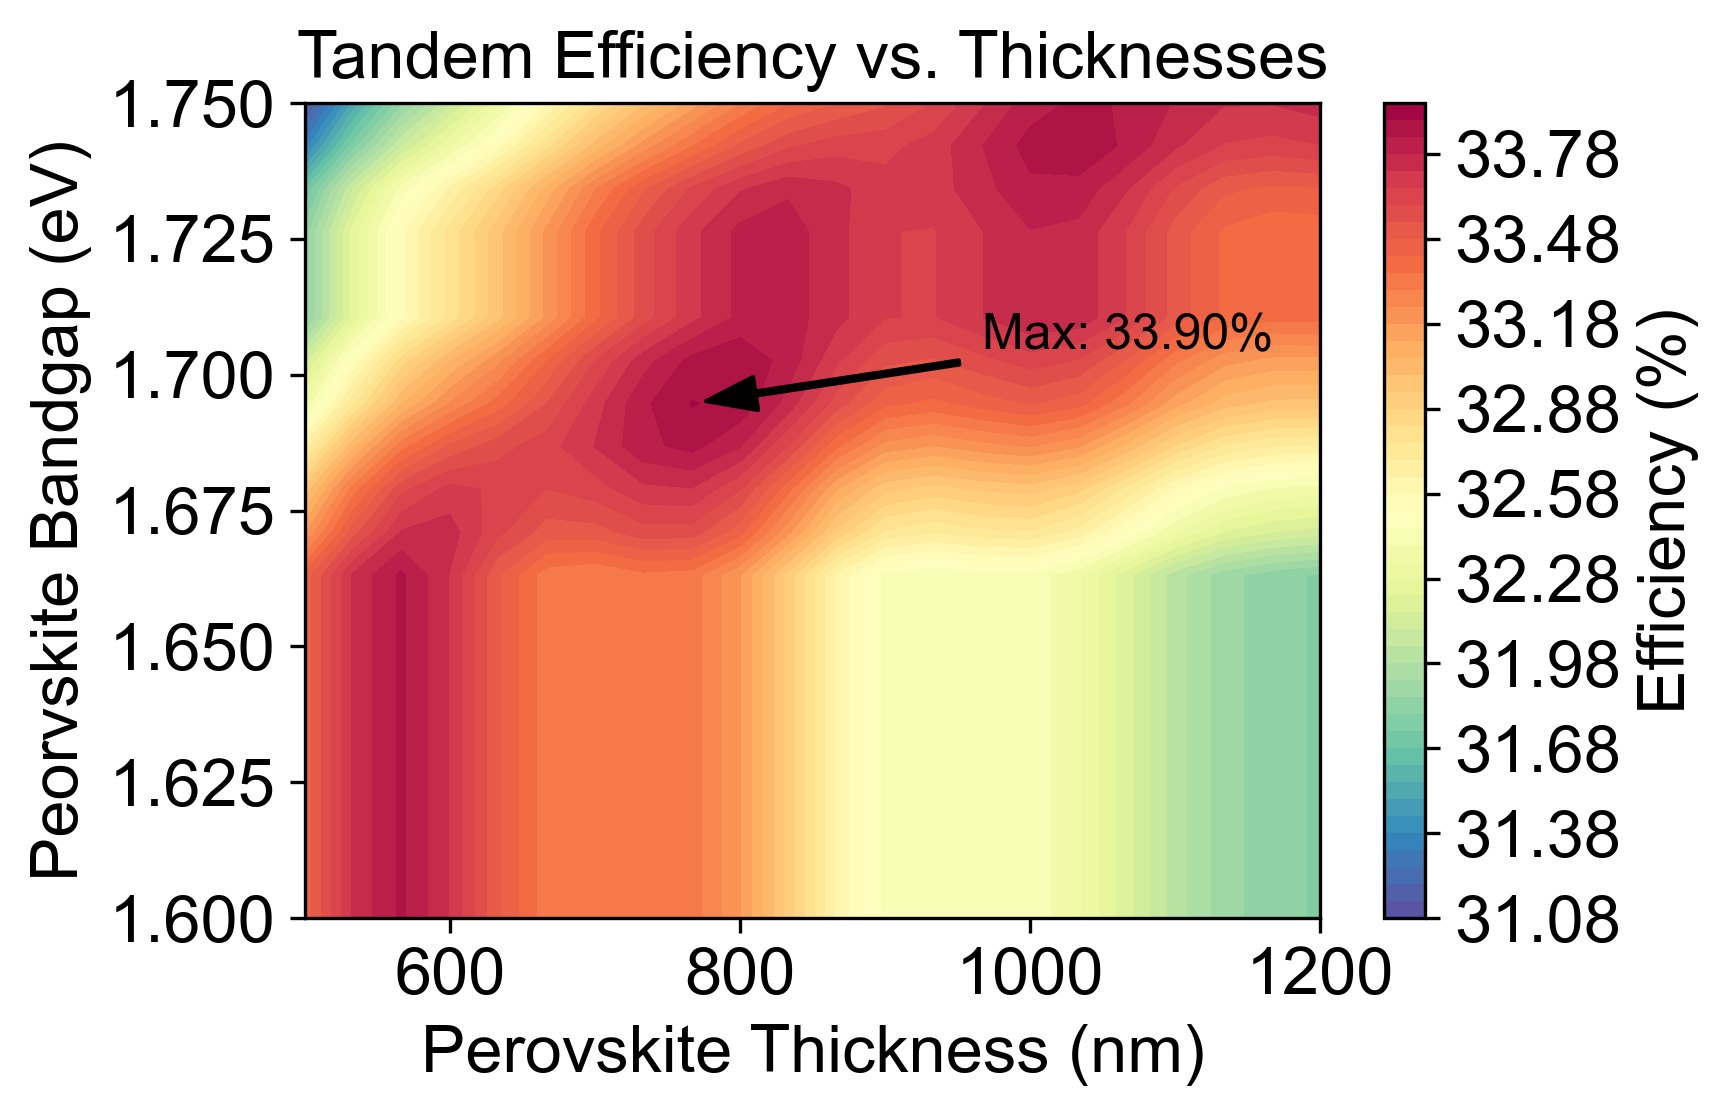

In [19]:
# plt.rcParams["figure.dpi"] = 300

plt.figure(figsize=(6, 4))
X, Y = np.meshgrid(pvk_thick_vec * 1e7, pvk_Egap_vec)  # pvk in nm, Si in eV
contour = plt.contourf(X, Y, eff_map, levels=50, cmap="Spectral_r")
cbar = plt.colorbar(contour, label="Efficiency (%)")
plt.xlabel("Perovskite Thickness (nm)")
plt.ylabel(r"Peorvskite Bandgap (eV)")
plt.title("Tandem Efficiency vs. Thicknesses")
plt.tight_layout()

# Find the max efficiency and its indices
max_eff = np.max(eff_map)
max_idx = np.unravel_index(np.argmax(eff_map), eff_map.shape)
max_x = (pvk_thick_vec * 1e7)[max_idx[1]]
max_y = pvk_Egap_vec[max_idx[0]]

# Plot arrow and text box
plt.annotate(
    f"Max: {max_eff:.2f}%",
    xy=(max_x, max_y),
    xytext=(max_x + 200, max_y + 0.01),
    arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=8),
    fontsize=12,
    ha="left",
)
print(f"Maximum efficiency at: Thickness = {max_x:.1f} nm, Bandgap = {max_y:.3f} eV")

plt.show()

# ...existing code...

Maximum Efficiency: 35.07 % at Si wafer thickness 1122.86 um and pvk thickness 828.57 nm


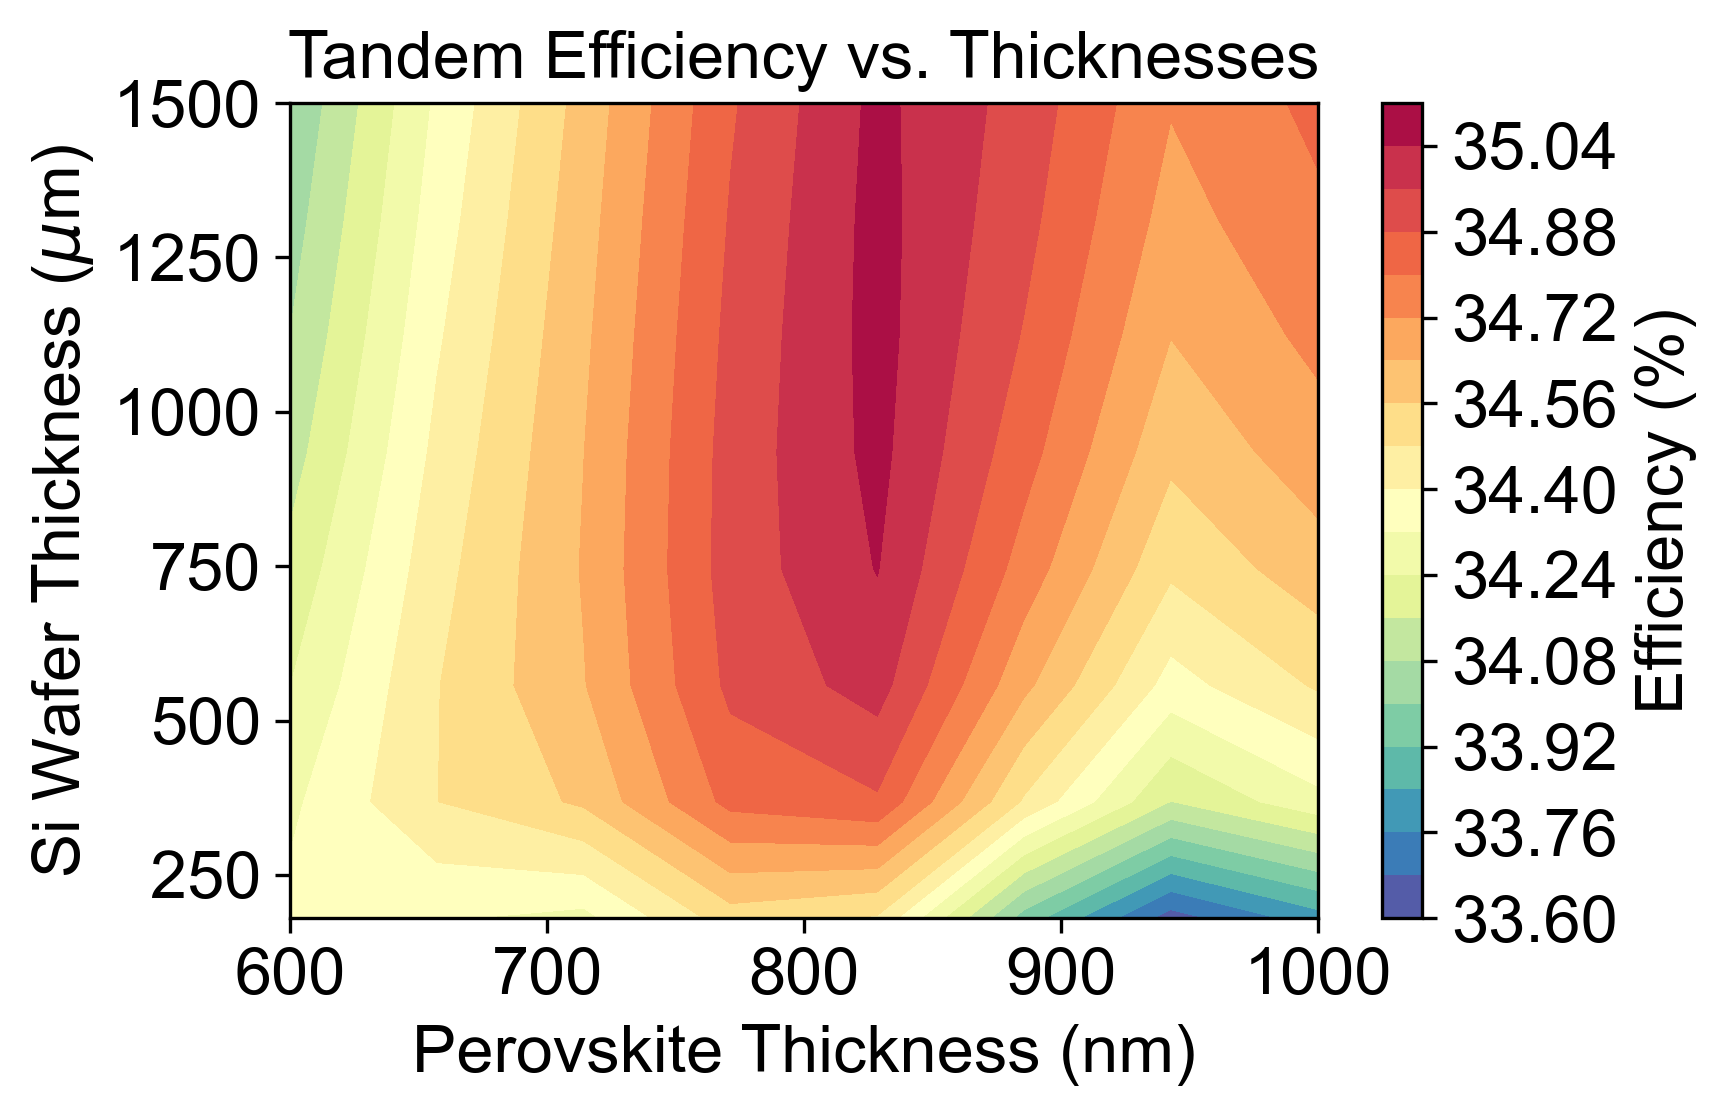

In [20]:
# Define ranges for Si wafer thickness and perovskite thickness (in cm)
top_cell_density = np.array([Jsc_pvk, Rsh_pvk, J01d_pvk, J0def_pvk, Rdef_pvk, J02_pvk])

Si_waf_thick_vec = np.linspace(0.018, 0.15, 8)  # e.g., 180um to 200um
pvk_thick_vec = np.linspace(600e-7, 1000e-7, 8)  # e.g., 500nm to 1500nm
TCE_thick = 40e-7  # cm
TCE_rho = 0.132e-3  # Ω·cm, example value for TCO
thicknesses = np.array(
    [0, 115, TCE_thick * 1e7, 10, 10, pvk_thick * 1e7, 1, 5000]
)  # (nm)

R_tco = TCE_rho / (TCE_thick)  # TCO sheet resistance (Ω/sq)

delta_n = np.logspace(15, 17, 200)  #
Vcell = np.linspace(1.5, 1.9, 100)  # the voltage range for the cell simulation
eff_map = np.zeros((len(Si_waf_thick_vec), len(pvk_thick_vec)))


for i, Si_waf_thick in enumerate(Si_waf_thick_vec):
    for j, pvk_thick in enumerate(pvk_thick_vec):
        # Update thicknesses array for current pvk and Si thickness
        thicknesses[pvk_layer_id] = pvk_thick * 1e7  # pvk in nm

        # series resistance for current thickness
        t_Aug, t_Rad, n_i_eff, _, _, _, _ = tandex.Si_bulk_lifetime(
            dop_type * Ndop, delta_n, Si_waf_thick, ni, T
        )
        tau_eff = 1 / (
            1 / t_Aug
            + 1 / t_Rad
            + (J0n_Si * (Ndop + delta_n) / (Si_waf_thick * q * n_i_eff**2))
        )
        rhs_Dn = Jsc_Si * tau_eff / (q * Si_waf_thick)
        delta_n2 = delta_n[np.argmin(np.abs(delta_n - rhs_Dn))]
        rho_Si = tandex.Si_res(delta_n2, Ndop)
        RserSi = rho_Si[0] * Si_waf_thick
        RserInt = RserSi

        # Update bottom cell density parameters for current Si thickness
        J0Aug_Si = q * C_aug * ni**3 * Si_waf_thick
        bottom_cell_density = np.array([Jsc_Si, Rsh_Si, J0_Si, J0Aug_Si, J0n_Si, n_def])

        # Run the optical-electronic efficiency calculation
        eff, *_ = tandex.optic_electronic_efficiency(
            Si_waf_thick,
            pvk_layer_id,
            R_tco,
            BB300K,
            layers,
            thicknesses,
            lambda_vec,
            AM15g,
            x_step,
            l_values,
            front_layers,
            top_cell_density,
            bottom_cell_density,
            w,
            d,
            Vcell,
            RserInt,
            df_pvk0,
            EgapP,
        )
        eff_map[i, j] = eff

print(
    f"Maximum Efficiency: {np.max(eff_map):.2f} % at Si wafer thickness {Si_waf_thick_vec[np.argmax(eff_map) // len(pvk_thick_vec)] * 1e4:.2f} um and pvk thickness {pvk_thick_vec[np.argmax(eff_map) % len(pvk_thick_vec)] * 1e7:.2f} nm"
)

# Plot the efficiency map
plt.figure(figsize=(6, 4))
X, Y = np.meshgrid(pvk_thick_vec * 1e7, Si_waf_thick_vec * 1e4)  # pvk in nm, Si in um
contour = plt.contourf(X, Y, eff_map, levels=20, cmap="Spectral_r")
cbar = plt.colorbar(contour, label="Efficiency (%)")
plt.xlabel("Perovskite Thickness (nm)")
plt.ylabel(r"Si Wafer Thickness ($\mu$m)")
plt.title("Tandem Efficiency vs. Thicknesses")
plt.tight_layout()
plt.show()

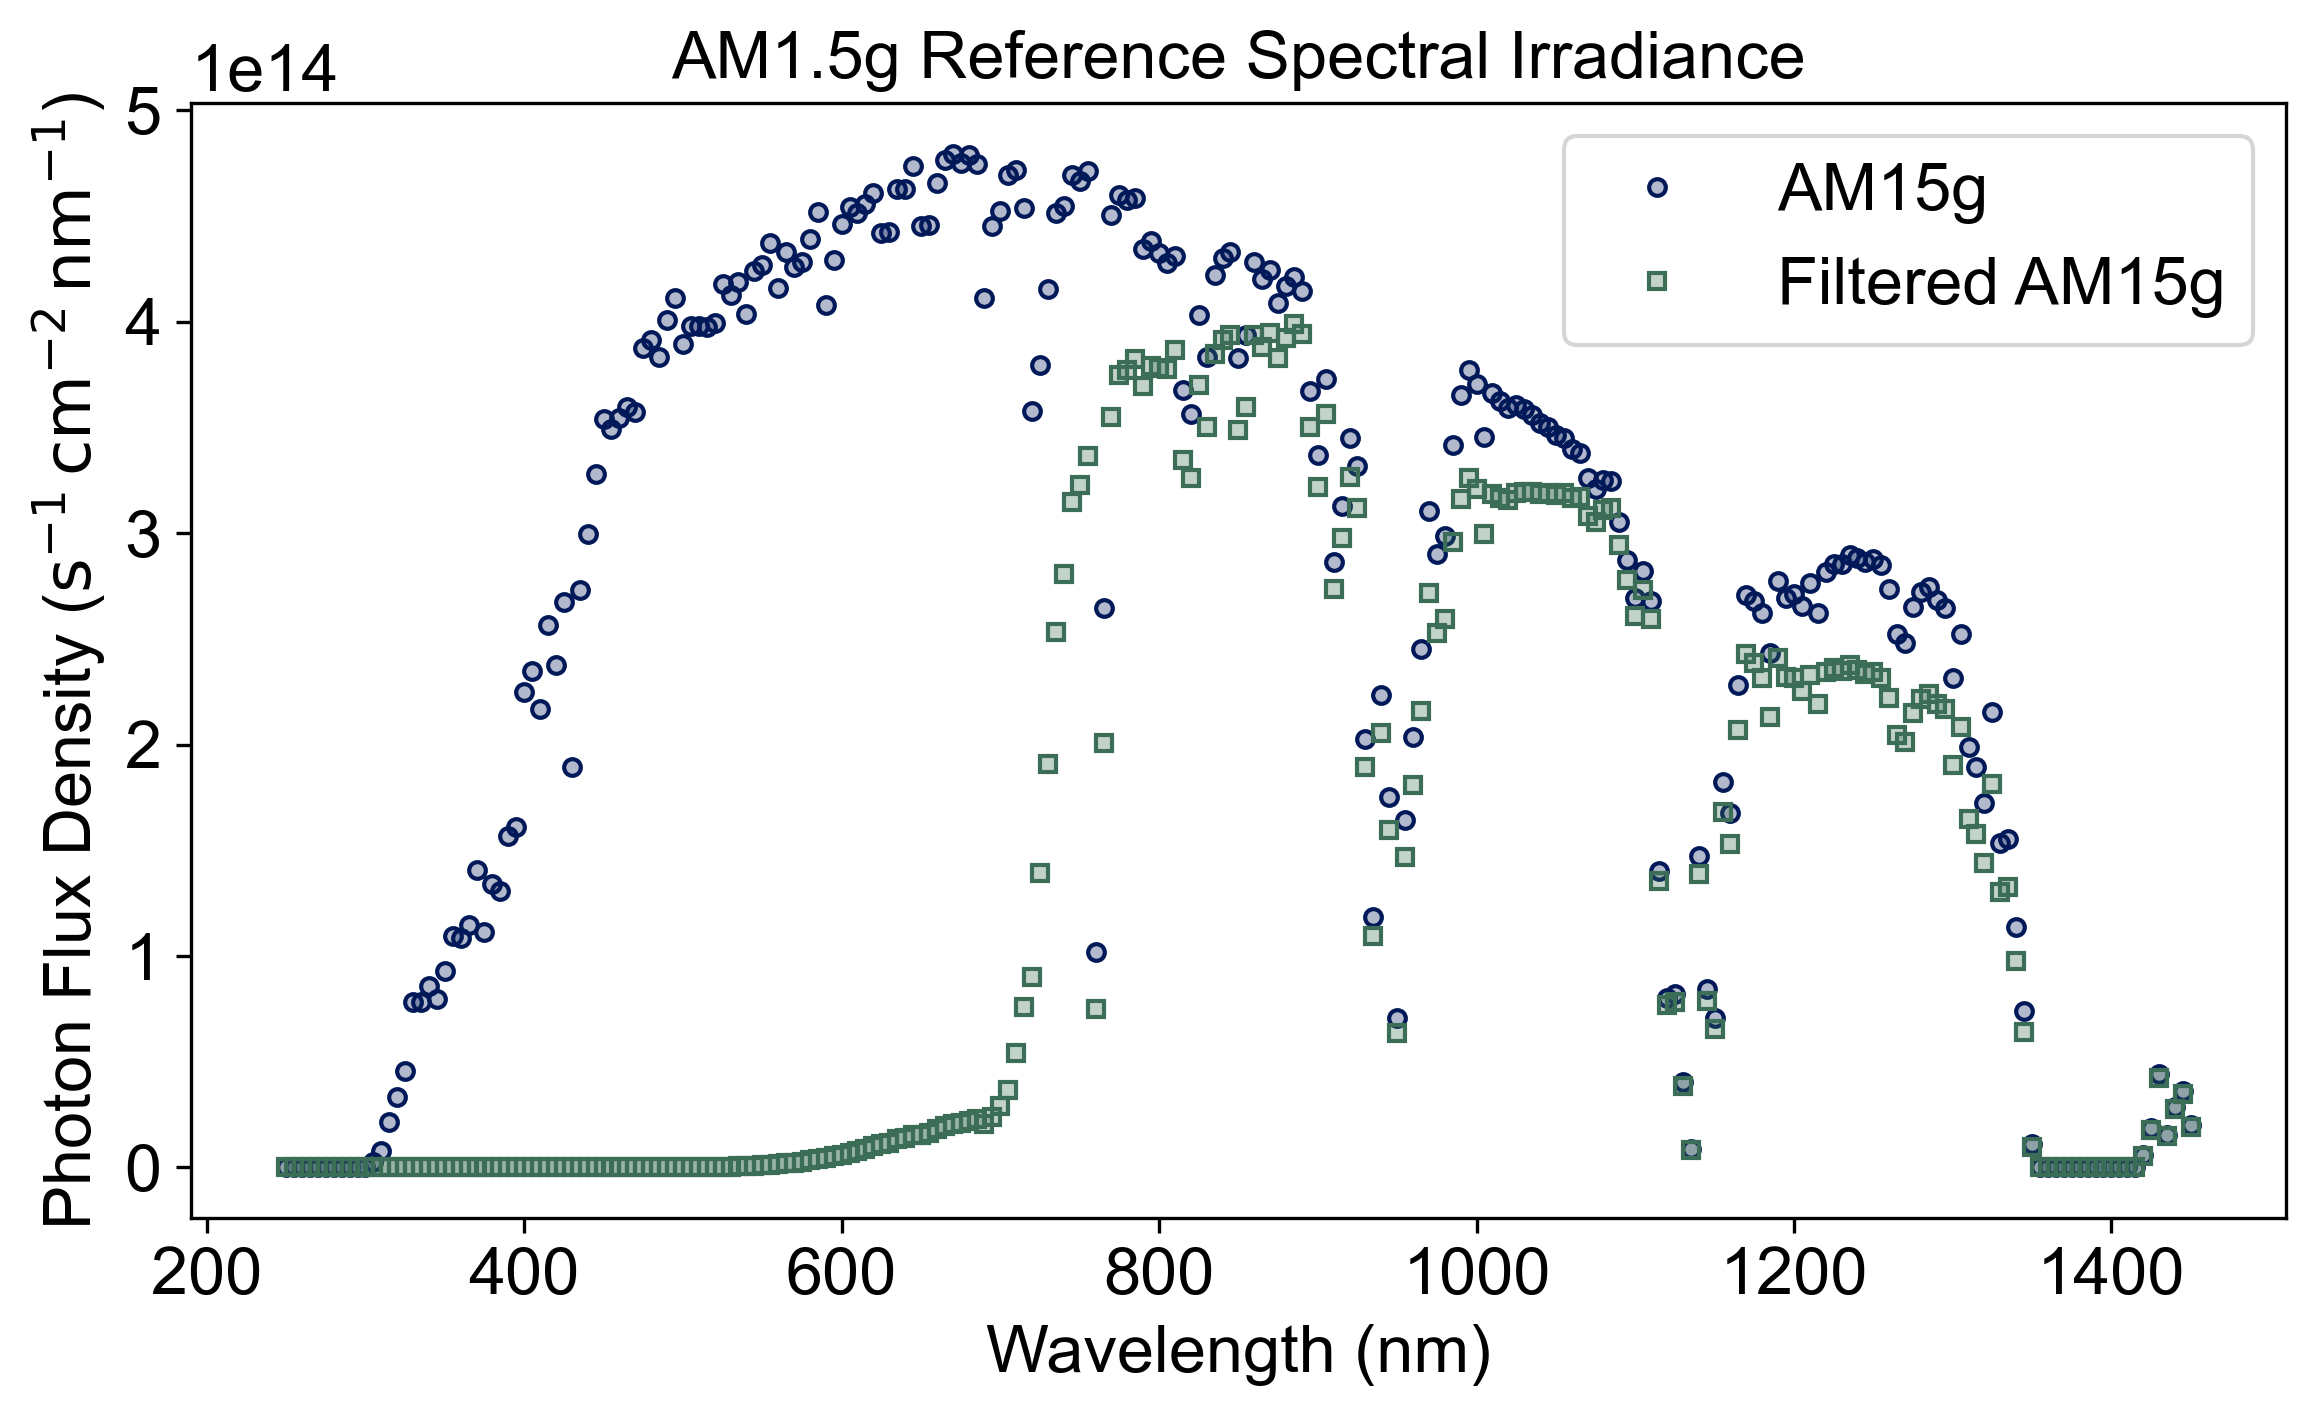

In [21]:
# Plot the filtered AM15g spectrum and the AM15g spectrum

plt.figure(figsize=(8, 5))
plt.plot(lambda_vec, AM15g, label="AM15g", markersize=4)
plt.plot(lambda_vec, FilteredAM15g, label="Filtered AM15g", markersize=4)
plt.title("AM1.5g Reference Spectral Irradiance")
plt.xlabel("Wavelength (nm)")
plt.ylabel(r"Photon Flux Density ($\mathrm{s^{-1}\,cm^{-2}\,nm^{-1}}$)")
plt.legend(loc="upper right")
plt.tight_layout()

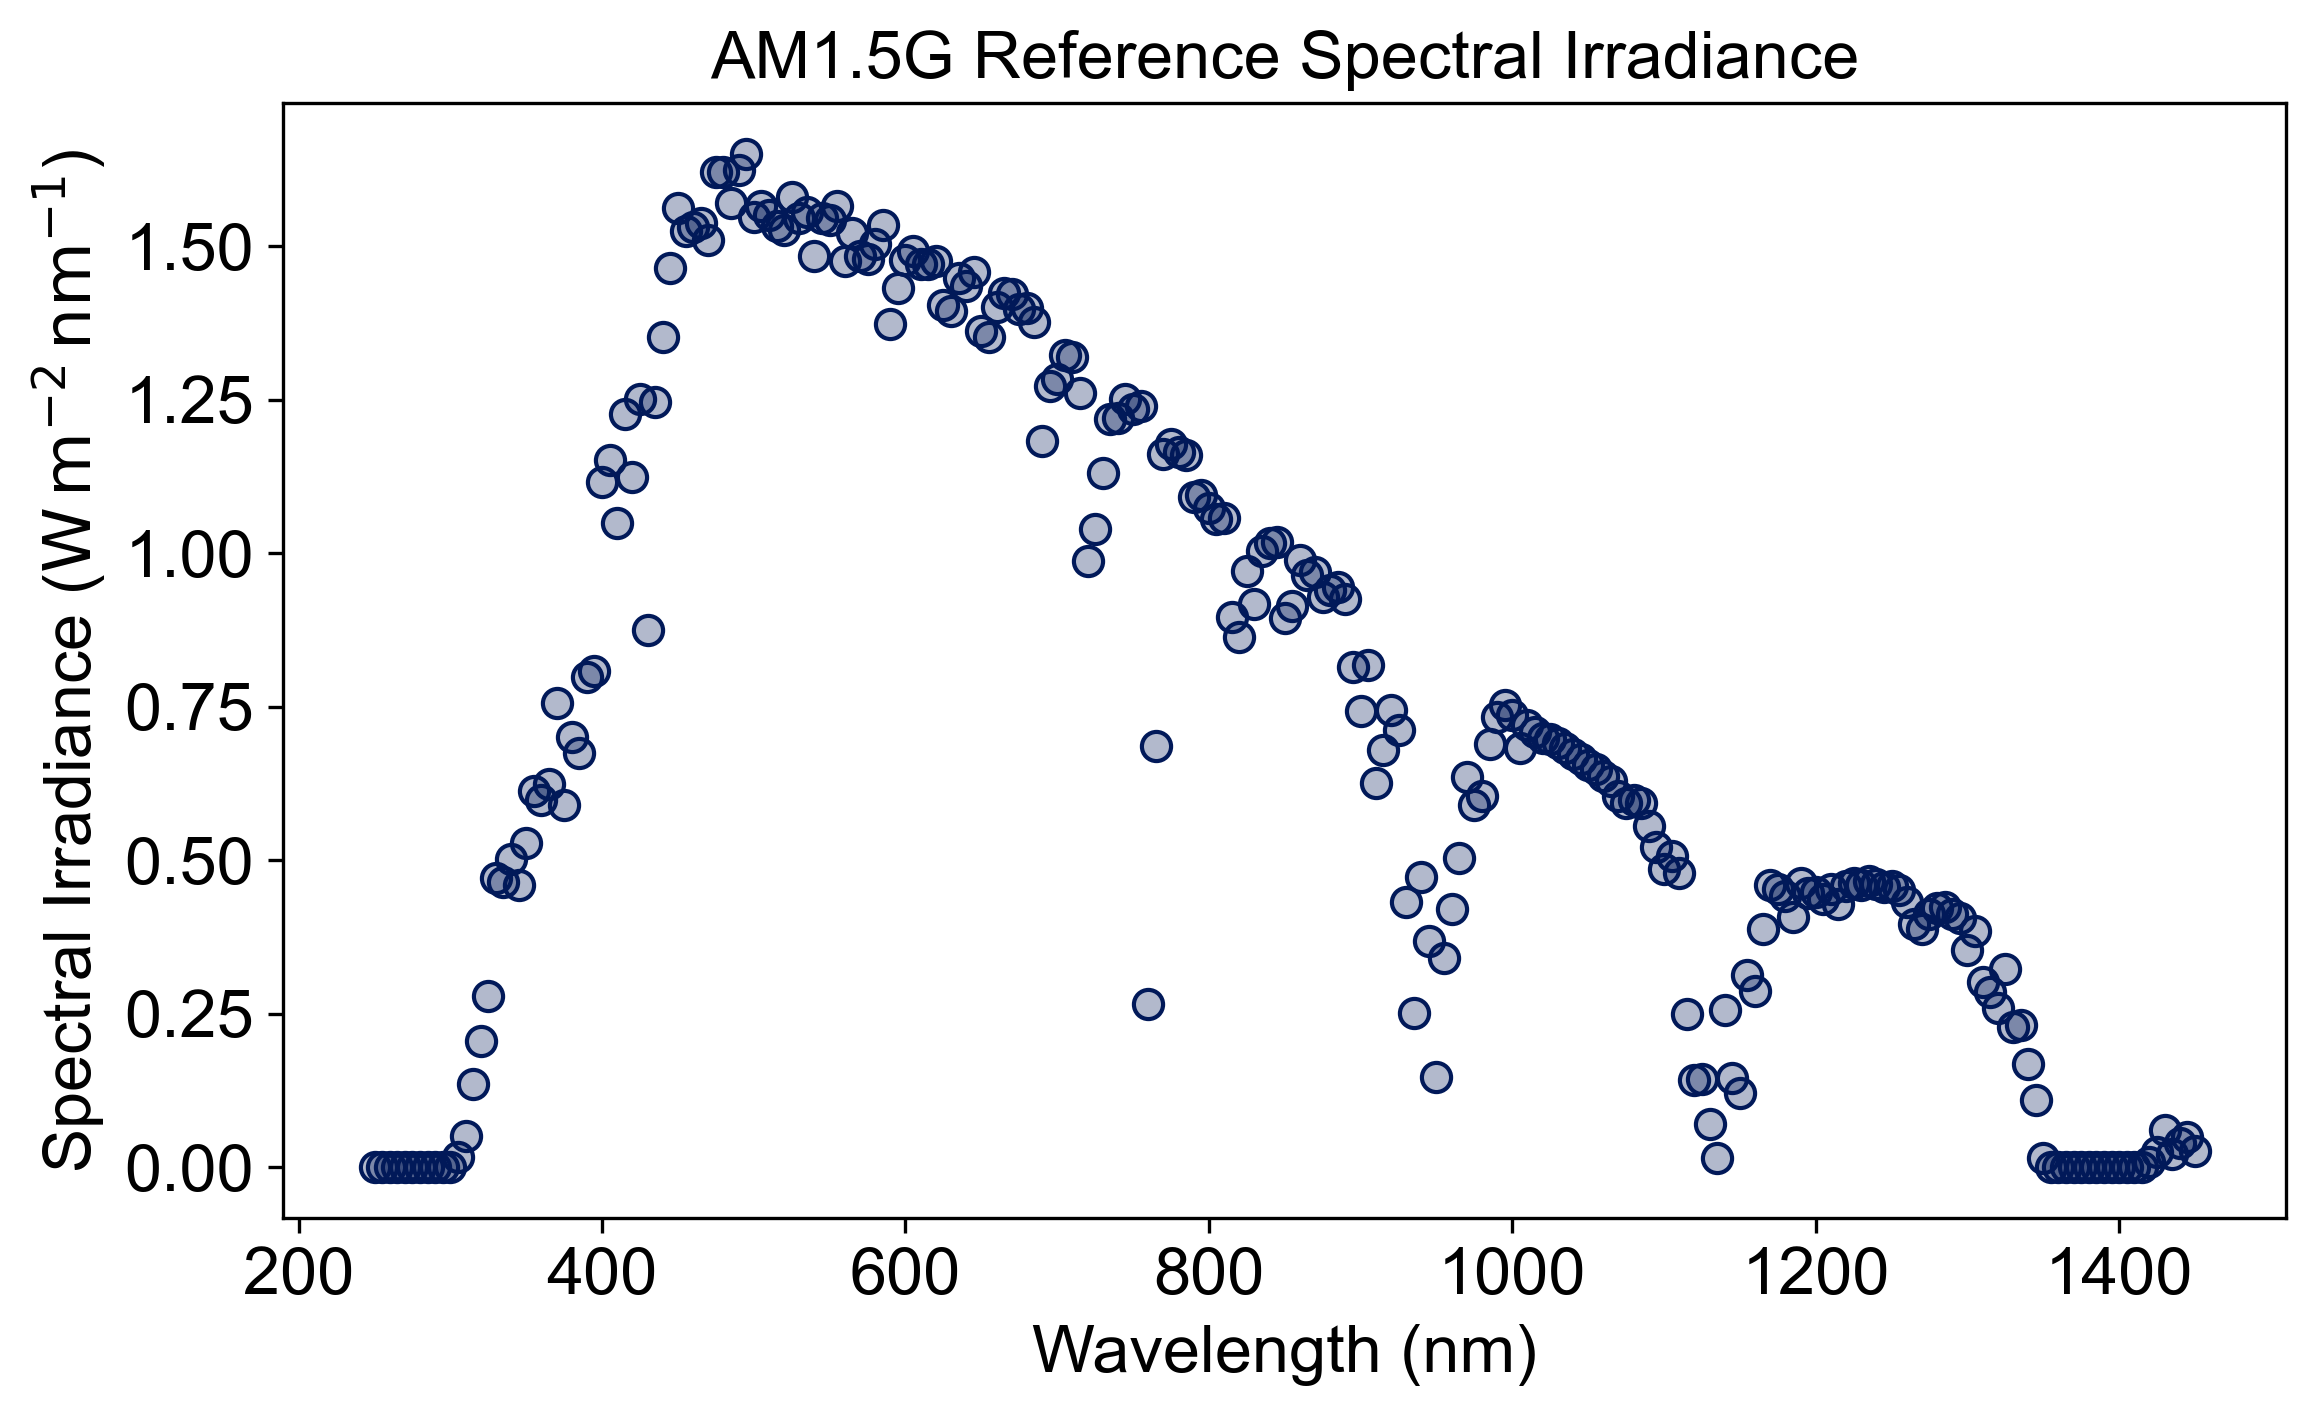

In [22]:
import numpy as np
import matplotlib.pyplot as plt

h = 6.62607015e-34   # J s
c = 299792458        # m/s

# wavelength: nm -> m
lambda_m = lambda_vec * 1e-9

# photon flux density -> spectral irradiance
# photons s^-1 cm^-2 nm^-1 -> W m^-2 nm^-1
AM15g_Wm2nm = AM15g * (h * c / lambda_m) * 1e4

plt.figure(figsize=(8, 5))

plt.plot(lambda_vec, AM15g_Wm2nm, label="AM1.5G")

plt.title("AM1.5G Reference Spectral Irradiance")
plt.xlabel("Wavelength (nm)")
plt.ylabel(r"Spectral Irradiance ($\mathrm{W\,m^{-2}\,nm^{-1}}$)")

#plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [23]:
am0 = pd.read_csv("./data/AM0.csv")

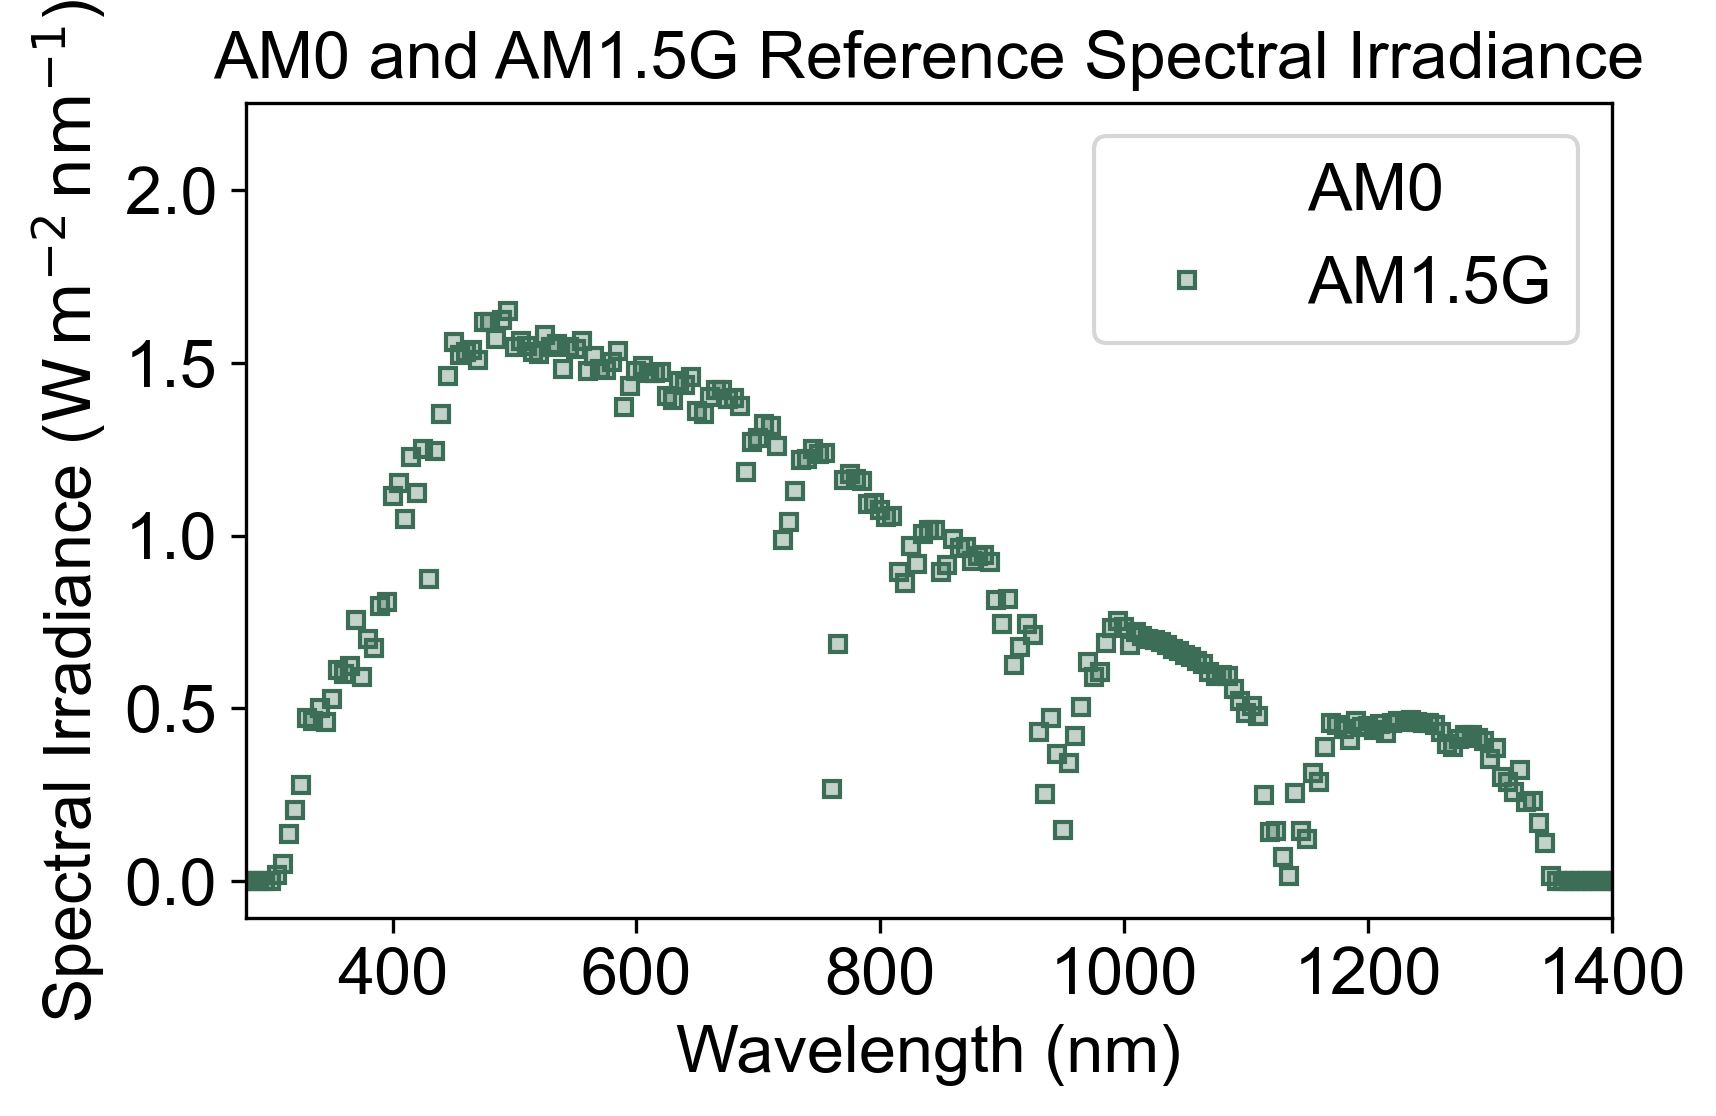

In [30]:
plt.plot(am0["Wavelength, nm"], am0["Wehrli, W/m2/nm"], label="AM0", markersize=4, alpha=0)
plt.plot(lambda_vec, AM15g_Wm2nm, label="AM1.5G", markersize=4)
plt.title("AM0 and AM1.5G Reference Spectral Irradiance")
plt.xlim(280, 1400)
plt.xlabel("Wavelength (nm)")
plt.ylabel(r"Spectral Irradiance ($\mathrm{W\,m^{-2}\,nm^{-1}}$)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()